# SHOW — 7 essential (+2 optional) · presentation figure deck

**One notebook that renders the nine figures chosen for the slides**, each pulled from the
pipeline stage where it is defined. The story arc is: *a single game is ambiguous (R2) →
but a **player** (many games) is a sharp fingerprint (R1, R3) → so “how many games?” has a
practical answer (R4) → yet that fingerprint is **deck-entangled**, not portable (R5, R6, R6b) →
here is the first partial fix (R6c).*

### How this deck is built
All figures render from **one parse** using the **V4 parser**
([`V4/playstyle_log_parse_v4.py`](V4/playstyle_log_parse_v4.py)), which is a strict superset —
it emits every V2, V3-trajectory/tell and V4 normalized/universal column, for **both** deck
families (`RenoKazakusMage`, `AggroPirateWarrior`). Each figure is then drawn with the *feature
set of the version it came from*, so it matches that version's own notebook:

| # | Figure (exact title in code) | Render from | Feature set | Why it earns a slide |
|---|------------------------------|-------------|-------------|----------------------|
| **R1** | Play-style fingerprints — per-style mean of each metric (z-score) | **V2**, Mage | 11 V2 metrics | The one interpretable “what a style looks like” visual |
| **R2** | §5 Per-game: PCA + t-SNE + KMeans confusion (ARI≈0.09) | **V2**, Mage | 11 V2 metrics | Proves one game overlaps — sets up the problem |
| **R3 ★** | §6 ARI-vs-N curve + fingerprint clouds (N=120) + confusion | **V2**, Mage | 11 V2 metrics | The headline: 0.09 → 0.99 |
| **R4** | Q1 · accuracy vs #games (per style) | **V4**, Mage | 29 (agnostic) | The practical answer (~35 games → 90%) |
| **R5** | Within-deck vs cross-deck transfer (bar) | **V4**, both | 3 feature sets | The open problem: collapse to ~0.24 |
| **R6** | Cross-deck per-style recall (heatmap) | **V4**, both | agnostic (29) | Only fatigue transfers |
| **R6b** | Cross-deck aggregate accuracy vs games pooled | **V4**, both | agnostic (29) | The clincher: pooling does *nothing* cross-deck → it's bias, not noise |
| **R7** *(opt)* | RF feature importance | **V2**, Mage | 11 V2 metrics | Which metrics carry style — support, not spine |
| **R6c** *(opt)* | Aggregated cross-deck: raw vs deck-normalised | **V4**, both | agnostic (29) | First partial fix (~0.30 → ~0.45) — future-work traction |

> **Provenance of the code.** R1/R2/R3/R7 are lifted from
> [`V2/…_v2.ipynb`](V2/playstyle_log_distribution_analysis_RenoKazakusMage_v2.ipynb) (§3/§5/§5b/§6);
> R4's §8 code is adapted from the V3-full notebook but rendered here on the **V4 agnostic** features
> ([`V4/…_v4.ipynb`](V4/playstyle_log_distribution_analysis_RenoKazakusMage_v4.ipynb));
> R5/R6/R6b from [`V4/…_v4.ipynb`](V4/playstyle_log_distribution_analysis_RenoKazakusMage_v4.ipynb) (§9);
> R6c from the reviewer follow-up (Prof. Kokolo #3b, domain-shift correction).

## 0 · Setup — one parse feeds every figure

Imports the **V4 parser**, parses both deck families into `games_all`, and defines the three
feature sets plus the shared helpers (`X2/y2` = the standardised V2-Mage matrix used by
R1/R2/R3/R7, and `cluster_confusion` used by R2/R3). Uses the on-disk cache
`playstyle_log_metrics_v4_bothdecks.pkl` — delete it to force a re-parse of the raw logs.

In [46]:
import os, sys, itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# --- anchor to the repo root regardless of the kernel CWD, then import the V4 parser ---
def _repo_root():
    """Nearest ancestor of the CWD holding both Log_Analysis/ and log/."""
    d = os.path.abspath(os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "Log_Analysis")) and os.path.isdir(os.path.join(d, "log")):
            return d
        if os.path.basename(d) == "Log_Analysis":
            return os.path.dirname(d)
        parent = os.path.dirname(d)
        if parent == d:
            raise FileNotFoundError("repo root with Log_Analysis/ and log/ not found from " + os.getcwd())
        d = parent
ROOT = _repo_root()
sys.path.insert(0, os.path.join(ROOT, "Log_Analysis", "V4"))
# The V4 parser is a SUPERSET: it emits every V2 + V3 (trajectory/tell) + V4 column,
# for BOTH deck families -> one parse can render figures from all three versions.
from playstyle_log_parse_v4 import (build_frames, BASE_DIR, DECKS,
    METRICS as V2_METRICS, TRAJ_METRICS, A_FEATURES, AGNOSTIC_FEATURES, RATIO_FEATURES)

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)

# stable order + one colour per play-style (used by every figure)
STYLE_ORDER  = ["aggro", "control", "fatigue", "midrange", "ramp"]
STYLE_COLORS = dict(zip(STYLE_ORDER, ["#d62728", "#1f77b4", "#9467bd", "#2ca02c", "#ff7f0e"]))

CACHE = os.path.join(BASE_DIR, "playstyle_log_metrics_v4_bothdecks.pkl")
games_all, cards_all, turns_all = build_frames(cache=CACHE, deck=DECKS)
games_all["style"] = pd.Categorical(games_all["style"], categories=STYLE_ORDER, ordered=True)

DECK_HOME  = "RenoKazakusMage"                              # "home" deck for the single-deck figures
games_mage = games_all[games_all["deck"] == DECK_HOME].copy()

# --- the three feature sets, each tagged with the version that defines it ---
FEATURES_V2 = list(V2_METRICS)                                            # 11  -> R1, R2, R3, R7
FEATURES_V3 = list(V2_METRICS) + list(TRAJ_METRICS) + list(A_FEATURES)    # 29  -> R4  (V3-full)
FEATURES_V4 = list(AGNOSTIC_FEATURES)                                     # 29  -> R5, R6, R6b, R6c

def standardize(df, feats):
    """Median-impute + z-score a feature block; return (X, y=style strings)."""
    from sklearn.preprocessing import StandardScaler
    Xr = df[feats].copy(); Xr = Xr.fillna(Xr.median())
    y  = df["style"].astype(str).values
    X  = StandardScaler().fit(Xr.values).transform(Xr.values)
    return X, y

# V2 (Mage) standardised matrix — shared by R1/R2/R3/R7
X2, y2 = standardize(games_mage, FEATURES_V2)

# map cluster ids -> styles (Hungarian on the contingency table) for readable confusion matrices
from scipy.optimize import linear_sum_assignment
def cluster_confusion(true_lab, clab, order=STYLE_ORDER):
    k = len(order)
    M = pd.crosstab(pd.Series(true_lab, name="style"), pd.Series(clab, name="cluster"))
    M = M.reindex(index=order).reindex(columns=range(k), fill_value=0).fillna(0)
    r, c = linear_sum_assignment(-M.values)
    col_to_style = {c[i]: order[r[i]] for i in range(len(r))}
    mapped = pd.Series(clab).map(lambda x: col_to_style.get(x, x)).values
    cm = pd.crosstab(pd.Series(true_lab, name="true style"),
                     pd.Series(mapped, name="cluster->style")).reindex(index=order, columns=order, fill_value=0)
    return cm, mapped

print(f"games_all {games_all.shape} | home deck '{DECK_HOME}' -> games_mage {games_mage.shape}")
print(f"feature-set sizes:  V2={len(FEATURES_V2)}  V3-full={len(FEATURES_V3)}  V4-agnostic={len(FEATURES_V4)}")
print("\ngames per deck/style:")
print(games_all.groupby(["deck", "style"], observed=True).size().to_string())

games_all (8992, 58) | home deck 'RenoKazakusMage' -> games_mage (4492, 58)
feature-set sizes:  V2=11  V3-full=29  V4-agnostic=29

games per deck/style:
deck                style   
AggroPirateWarrior  aggro       900
                    control     900
                    fatigue     900
                    midrange    900
                    ramp        900
RenoKazakusMage     aggro       900
                    control     898
                    fatigue     899
                    midrange    899
                    ramp        896


## R1 · Play-style fingerprints — per-style mean of each metric (z-score)

* **From:** V2 · `RenoKazakusMage` · 11 V2 metrics · source §3 (cell `c3ca5a15`, heatmap half).
* **Why a slide:** the one interpretable *“what a style looks like”* visual — each column is a
  metric, each row a style, colour = how many σ that style sits from the 5-style average
  (annotations are the raw means). Read the red/blue bands: aggro = high face-attack & attacks/turn,
  fatigue = long games & high cards-in-hand, ramp = high mana, etc.
* **Note:** z-scored *across the 5 styles* so a subtle-but-consistent tell is as visible as a loud one.

,n_my_turns,avg_cards_in_hand,mana_eff,avg_card_cost,minion_fraction,face_attack_ratio,attacks_per_turn,enemy_minions_killed_per_turn,avg_board_minions,taken_dmg_per_turn,hp_per_turn
style,,,,,,,,,,,
aggro,6.820,5.416,0.566,3.056,0.439,0.839,0.183,0.022,0.058,5.589,0.536
control,9.939,4.490,0.722,3.322,0.517,0.651,0.474,0.185,0.153,3.497,0.314
fatigue,9.174,4.601,0.680,3.240,0.494,0.761,0.397,0.151,0.117,4.027,0.347
midrange,10.633,4.510,0.734,3.585,0.521,0.693,0.606,0.169,0.164,2.851,0.280
ramp,11.241,4.516,0.740,3.632,0.537,0.607,0.667,0.177,0.197,2.557,0.272


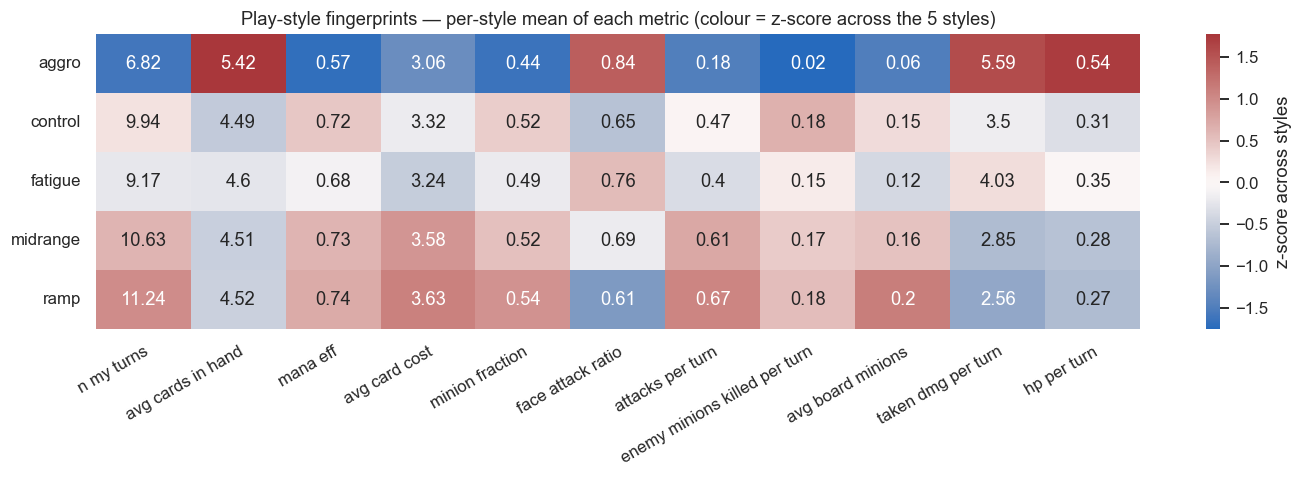

In [47]:
# R1 — Play-style fingerprints (V2, Mage, 11 metrics)
mean_tbl = games_mage.groupby("style", observed=True)[FEATURES_V2].mean().reindex(STYLE_ORDER)
z = (mean_tbl - mean_tbl.mean()) / mean_tbl.std()
display(mean_tbl.round(3))
fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(z, annot=mean_tbl.round(2), fmt="", cmap="vlag", center=0, ax=ax,
            cbar_kws={"label": "z-score across styles"})
ax.set_title("Play-style fingerprints — per-style mean of each metric (colour = z-score across the 5 styles)")
ax.set_ylabel("")                                              # 'style' axis title is redundant
# keep the 5 style names upright, and angle the long metric names so they don't collide/clip
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center")
ax.set_xticklabels([t.get_text().replace("_", " ") for t in ax.get_xticklabels()],
                   rotation=30, ha="right", rotation_mode="anchor")
fig.tight_layout(); plt.show()

## R2 · §5 Per-game: PCA + t-SNE + KMeans confusion (ARI ≈ 0.09)

* **From:** V2 · `RenoKazakusMage` · 11 V2 metrics · source §5 (cell `290fb203`).
* **Why a slide:** it *sets up the problem*. At the **single-game** level the 5 styles mostly
  overlap — PCA and t-SNE show tangled point clouds and unsupervised KMeans(k=5) barely beats
  random (ARI ≈ 0.09). One game is not enough to name a style.
* **Reads with R3:** R2 is the "before" (one game), R3 is the "after" (pool games).

Per-game unsupervised clustering vs the 5 true styles
  KMeans : ARI=0.094  AMI=0.132  silhouette=0.137
  GMM    : ARI=0.074  AMI=0.105  silhouette=0.066


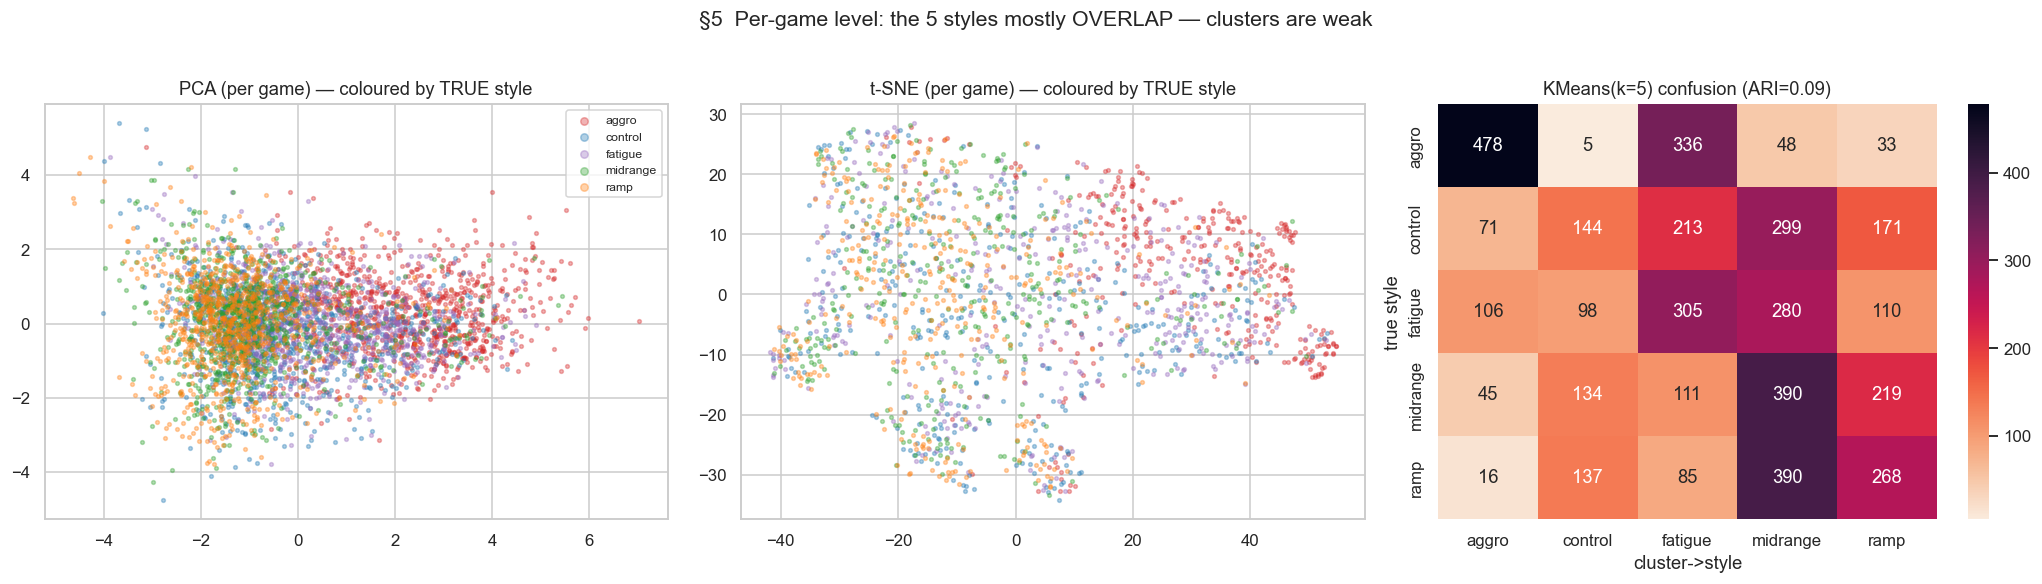

In [48]:
# R2 — §5 per-game projection & clustering (uses X2/y2 and cluster_confusion from setup)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, silhouette_score

pca = PCA(n_components=2, random_state=0).fit(X2)
P = pca.transform(X2)
rng = np.random.default_rng(0)
sub = rng.choice(len(X2), size=min(1800, len(X2)), replace=False)   # t-SNE on a subsample (speed)
T = TSNE(n_components=2, init="pca", perplexity=40, random_state=0).fit_transform(X2[sub])

km = KMeans(5, n_init=10, random_state=0).fit(X2)
gm = GaussianMixture(5, covariance_type="full", random_state=0).fit(X2)
km_lab, gm_lab = km.labels_, gm.predict(X2)

print("Per-game unsupervised clustering vs the 5 true styles")
for name, lab in [("KMeans", km_lab), ("GMM", gm_lab)]:
    print(f"  {name:7s}: ARI={adjusted_rand_score(y2, lab):.3f}  "
          f"AMI={adjusted_mutual_info_score(y2, lab):.3f}  silhouette={silhouette_score(X2, lab):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(19, 5.4))
for st in STYLE_ORDER:
    m = (y2 == st); ax[0].scatter(P[m, 0], P[m, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
    ms = (y2[sub] == st); ax[1].scatter(T[ms, 0], T[ms, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
ax[0].set_title("PCA (per game) — coloured by TRUE style"); ax[0].legend(fontsize=8, markerscale=2)
ax[1].set_title("t-SNE (per game) — coloured by TRUE style")
cm, _ = cluster_confusion(y2, km_lab)
sns.heatmap(cm, annot=True, fmt="d", cmap="rocket_r", ax=ax[2])
ax[2].set_title(f"KMeans(k=5) confusion (ARI={adjusted_rand_score(y2, km_lab):.2f})")
for a in ax[:2]:
    a.set_xlabel(""); a.set_ylabel("")
fig.suptitle("§5  Per-game level: the 5 styles mostly OVERLAP — clusters are weak", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## R3 ★ · §6 ARI-vs-N curve + fingerprint clouds (N=120) + confusion

* **From:** V2 · `RenoKazakusMage` · 11 V2 metrics · source §6 (cell `5cf70b12`).
* **Why a slide (the headline):** aggregate a *player* (N games averaged into one fingerprint)
  and the cluster–style ARI climbs from **≈ 0.09 at N=1 to ≈ 0.99 at N=120**. Left: ARI &
  silhouette vs N. Middle: the N=120 fingerprint clouds now split into five clean clusters.
  Right: the KMeans-vs-true confusion is almost diagonal. Same 11 metrics as R2 — the only thing
  that changed is *how many games* define the player.

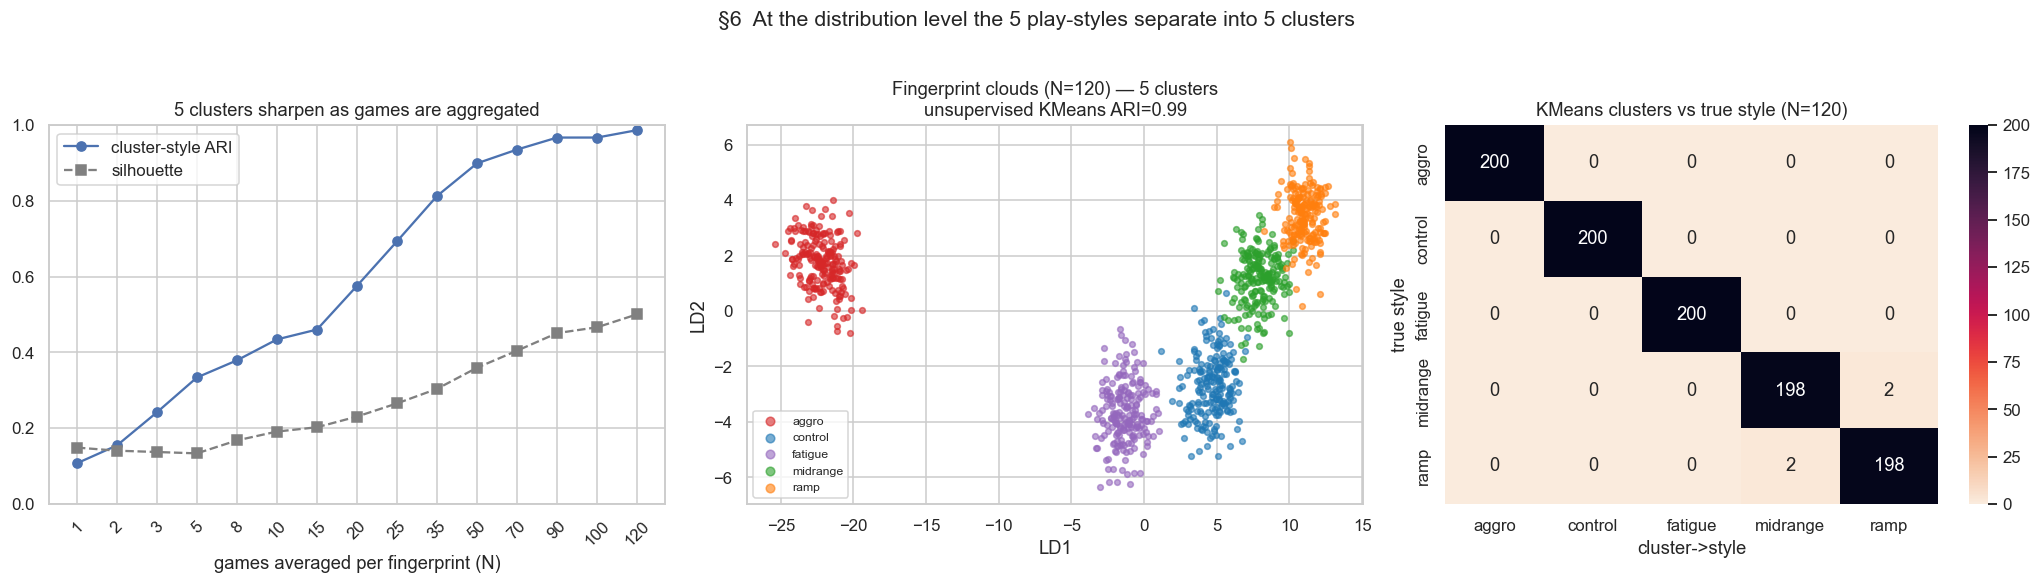

unsupervised KMeans(k=5) on N=120 fingerprints:  ARI=0.990


In [49]:
# R3 — §6 the 5 clusters emerge as games are aggregated (uses X2/y2, cluster_confusion)
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def bootstrap_fingerprints(N, reps=150, seed=0):
    rng = np.random.default_rng(seed)
    rows, lab = [], []
    for st in STYLE_ORDER:
        a = X2[y2 == st]
        for _ in range(reps):
            rows.append(a[rng.integers(0, len(a), N)].mean(axis=0)); lab.append(st)
    return np.array(rows), np.array(lab)

# ARI of unsupervised KMeans(k=5) on the fingerprints, as a function of N
Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
aris, sils = [], []
for N in Ns:
    Xb, yb = bootstrap_fingerprints(N)
    lab = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)
    aris.append(adjusted_rand_score(yb, lab)); sils.append(silhouette_score(Xb, lab))

# a clean picture at a representative N
Xb, yb = bootstrap_fingerprints(120, reps=200)
labb = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)
ari_b = adjusted_rand_score(yb, labb)
Lb = LinearDiscriminantAnalysis(n_components=2).fit(Xb, yb).transform(Xb)

fig, ax = plt.subplots(1, 3, figsize=(19, 5.4))
_xs = range(len(Ns))
ax[0].plot(_xs, aris, "o-", label="cluster-style ARI")
ax[0].plot(_xs, sils, "s--", color="gray", label="silhouette")
ax[0].set_xticks(list(_xs)); ax[0].set_xticklabels(Ns, rotation=45)
ax[0].set_xlabel("games averaged per fingerprint (N)")
ax[0].set_title("5 clusters sharpen as games are aggregated"); ax[0].legend(); ax[0].set_ylim(0, 1)
for st in STYLE_ORDER:
    m = (yb == st); ax[1].scatter(Lb[m, 0], Lb[m, 1], s=14, alpha=.6, color=STYLE_COLORS[st], label=st)
ax[1].set_title(f"Fingerprint clouds (N=120) — 5 clusters\nunsupervised KMeans ARI={ari_b:.2f}")
ax[1].legend(fontsize=8, markerscale=1.5); ax[1].set_xlabel("LD1"); ax[1].set_ylabel("LD2")
cmb, _ = cluster_confusion(yb, labb)
sns.heatmap(cmb, annot=True, fmt="d", cmap="rocket_r", ax=ax[2])
ax[2].set_title("KMeans clusters vs true style (N=120)")
fig.suptitle("§6  At the distribution level the 5 play-styles separate into 5 clusters", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
print(f"unsupervised KMeans(k=5) on N=120 fingerprints:  ARI={ari_b:.3f}")

## R4 · Q1 · accuracy vs #games (per style)

* **From:** V4 · `RenoKazakusMage` · **29 agnostic features** (deck-normalized / universal)
  · source §8 (cell `74d23828`).
* **Why a slide:** the *practical* answer to “how many games do I need to name a player's style?”
  A held-out LDA trained on N-game fingerprints reaches **~90% around N ≈ 35** overall; the per-style
  curves show `aggro` is a near-giveaway from a single game while the value styles need pooling.
  The extra V4 features (vs R3's 11) lift the small-N accuracy.
* **Panels:** accuracy-vs-N per style · per-style accuracy heatmap across N · single-game confusion (Q2).

Smallest N (games averaged) to reach accuracy:
  overall (LDA) >= 80%: N = 15
  overall (LDA) >= 90%: N = 35
  per style >= 90%:  aggro: 2 | control: 35 | fatigue: 8 | midrange: 50 | ramp: 70

Single-game accuracy: 0.485  (chance 0.20)  -> aggro is a giveaway; the rest need pooling


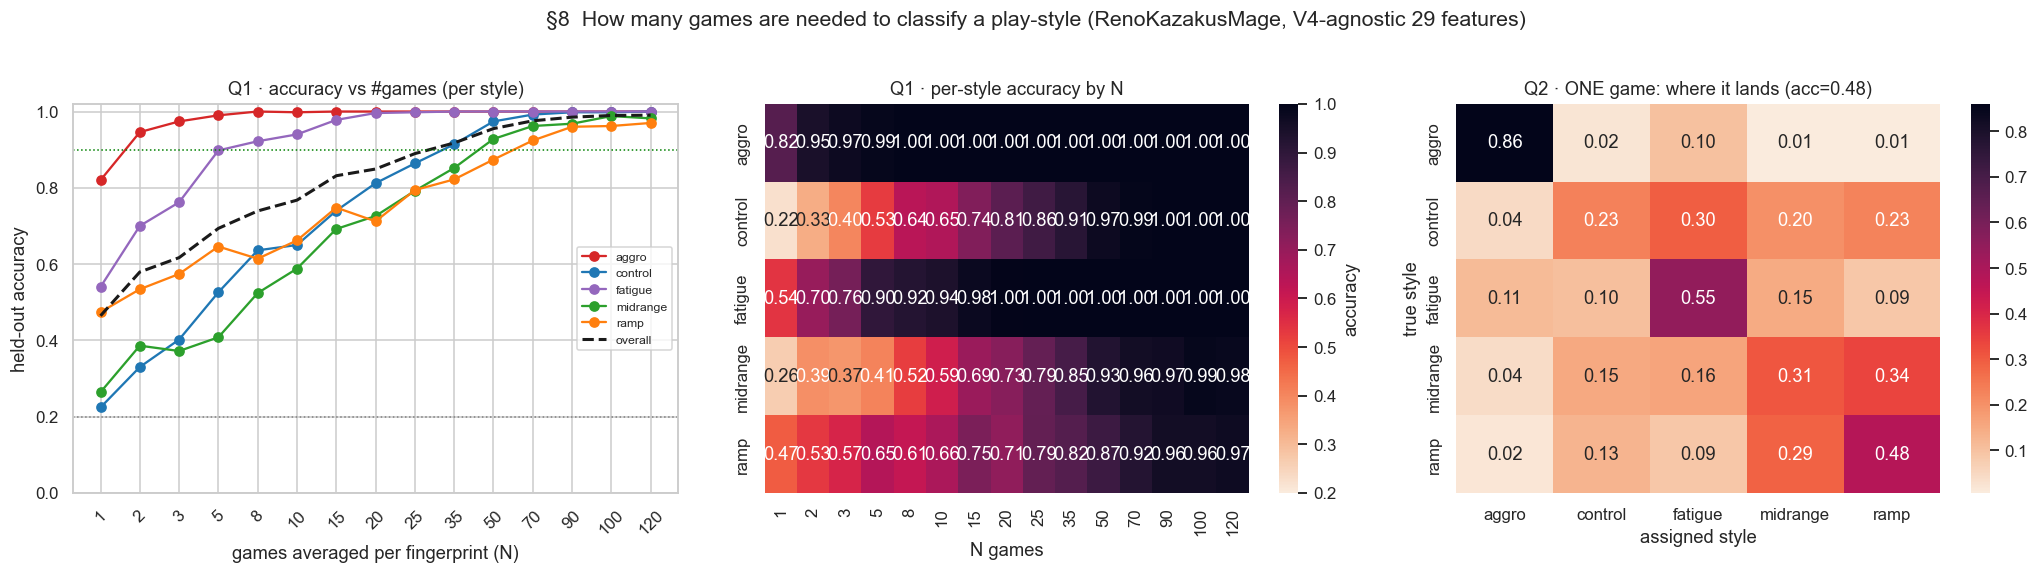

,overall (LDA),overall (centroid),aggro,control,fatigue,midrange,ramp
N,,,,,,,
1,0.464,0.413,0.820,0.224,0.540,0.264,0.474
2,0.579,0.502,0.946,0.330,0.700,0.386,0.534
3,0.617,0.579,0.974,0.402,0.762,0.372,0.574
5,0.694,0.638,0.990,0.526,0.898,0.408,0.646
8,0.739,0.684,1.000,0.636,0.922,0.524,0.614
10,0.768,0.716,0.998,0.650,0.940,0.588,0.662
15,0.832,0.771,1.000,0.740,0.978,0.692,0.748
20,0.849,0.812,1.000,0.812,0.996,0.726,0.712
25,0.890,0.834,1.000,0.864,0.998,0.792,0.794


In [50]:
# R4 — §8 Q1 accuracy vs #games, on the V4 agnostic 29-feature set (Mage)
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix

FEATURES = FEATURES_V4   # V4 agnostic: 29 deck-normalized features

# --- held-out 50/50 split within each style (disjoint games) ---
rng = np.random.default_rng(1)
G = games_mage.copy(); G[FEATURES] = G[FEATURES].fillna(G[FEATURES].median())
tr_idx, te_idx = [], []
for st in STYLE_ORDER:
    idx = G.index[G["style"] == st].to_numpy().copy(); rng.shuffle(idx)
    h = len(idx) // 2; tr_idx += list(idx[:h]); te_idx += list(idx[h:])
tr, te = G.loc[tr_idx], G.loc[te_idx]
sc8 = StandardScaler().fit(tr[FEATURES].values)
Xtr, Xte = sc8.transform(tr[FEATURES].values), sc8.transform(te[FEATURES].values)
ytr, yte = tr["style"].astype(str).values, te["style"].astype(str).values
trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}
teby = {s: Xte[yte == s] for s in STYLE_ORDER}
Cen  = np.vstack([trby[s].mean(0) for s in STYLE_ORDER])   # train fingerprint centroids = the 5 clusters

def make_fps(by, N, reps, seed):
    r = np.random.default_rng(seed); Xs, ys = [], []
    for si, s in enumerate(STYLE_ORDER):
        a = by[s]
        for _ in range(reps):
            Xs.append(a[r.integers(0, len(a), N)].mean(0)); ys.append(si)
    return np.array(Xs), np.array(ys)

# --- Q1: accuracy vs N (LDA model; nearest-centroid for reference) ---
Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
rows = []
for N in Ns:
    Xa, ya = make_fps(trby, N, 500, 10)
    lda = LinearDiscriminantAnalysis().fit(Xa, ya)
    Xb, yb = make_fps(teby, N, 500, 20)
    p_lda = lda.predict(Xb)
    p_nc  = (((Xb[:, None] - Cen[None]) ** 2).sum(2)).argmin(1)
    row = {"N": N, "overall (LDA)": (p_lda == yb).mean(), "overall (centroid)": (p_nc == yb).mean()}
    for si, s in enumerate(STYLE_ORDER):
        row[s] = (p_lda[yb == si] == si).mean()
    rows.append(row)
acc = pd.DataFrame(rows).set_index("N")

def first_N(col, thr):
    hit = acc.index[acc[col] >= thr]
    return int(hit[0]) if len(hit) else f">{Ns[-1]}"
print("Smallest N (games averaged) to reach accuracy:")
for thr in (0.80, 0.90):
    print(f"  overall (LDA) >= {thr:.0%}: N = {first_N('overall (LDA)', thr)}")
print("  per style >= 90%:  " + " | ".join(f"{s}: {first_N(s, 0.90)}" for s in STYLE_ORDER))

# --- Q2: single held-out game, classified once each ---
lda1 = LinearDiscriminantAnalysis().fit(Xtr, ytr)
cm1 = confusion_matrix(yte, lda1.predict(Xte), labels=STYLE_ORDER, normalize="true")
print(f"\nSingle-game accuracy: {np.trace(cm1) / 5:.3f}  (chance 0.20)  -> aggro is a giveaway; the rest need pooling")

fig, ax = plt.subplots(1, 3, figsize=(19, 5.3))
# panel 1: accuracy vs N
_xs = range(len(acc.index))
for s in STYLE_ORDER:
    ax[0].plot(_xs, acc[s], "o-", color=STYLE_COLORS[s], label=s)
ax[0].plot(_xs, acc["overall (LDA)"], "k--", lw=2, label="overall")
ax[0].axhline(0.2, color="gray", ls=":", lw=1); ax[0].axhline(0.9, color="green", ls=":", lw=1)
ax[0].set_xticks(list(_xs)); ax[0].set_xticklabels(acc.index, rotation=45); ax[0].set_ylim(0, 1.02)
ax[0].set_xlabel("games averaged per fingerprint (N)")
ax[0].set_ylabel("held-out accuracy"); ax[0].set_title("Q1 · accuracy vs #games (per style)"); ax[0].legend(fontsize=8)
# panel 2: per-style accuracy heatmap across N
hm = acc[STYLE_ORDER].T
sns.heatmap(hm, annot=True, fmt=".2f", cmap="rocket_r", vmin=0.2, vmax=1.0, ax=ax[1],
            cbar_kws={"label": "accuracy"})
ax[1].set_title("Q1 · per-style accuracy by N"); ax[1].set_xlabel("N games"); ax[1].set_ylabel("")
# panel 3: single-game confusion
sns.heatmap(pd.DataFrame(cm1, index=STYLE_ORDER, columns=STYLE_ORDER), annot=True, fmt=".2f",
            cmap="rocket_r", ax=ax[2])
ax[2].set_title(f"Q2 · ONE game: where it lands (acc={np.trace(cm1)/5:.2f})")
ax[2].set_ylabel("true style"); ax[2].set_xlabel("assigned style")
fig.suptitle("§8  How many games are needed to classify a play-style (RenoKazakusMage, V4-agnostic 29 features)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
display(acc.style.format("{:.3f}").background_gradient(cmap="rocket_r", subset=STYLE_ORDER + ["overall (LDA)"])
        .set_caption("Held-out accuracy of an N-game fingerprint (V4-agnostic features)"))

## R5 · Within-deck vs cross-deck transfer (bar)

* **From:** V4 · **both** deck families · source §9a (cell `v4xdeck_rf`).
* **Why a slide (the open problem):** everything above lived on **one** deck. Train a RandomForest
  on one deck and score the **other** and the accuracy collapses toward chance (~0.24 vs 0.20). The AI's
  “style” is **entangled with the deck**, not a free-floating fingerprint.
* **The comparison is the point:** the **V4 agnostic** features transfer *better* than the deck-leaky
  V3-full set while matching it within-deck — normalization removed deck-identity leakage without
  discarding behaviour. This cell defines `FEATURE_SETS`, `cross_rf`, `DA/DB` reused by R6/R6b.

,within_Mage,within_Warrior,cross_M2W,cross_W2M
feature_set,,,,
V3-full deck-leaky (29),0.489,0.393,0.224,0.235
V4 agnostic (29),0.503,0.393,0.242,0.254
V4 pure-ratio (17),0.459,0.335,0.208,0.239


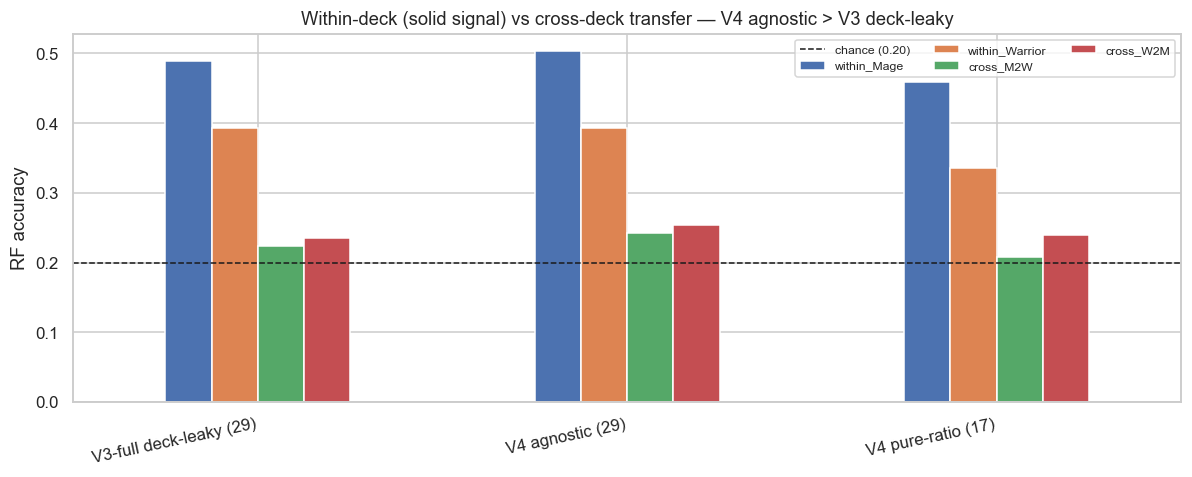

In [51]:
# R5 — §9a within-deck (reference) vs cross-deck RandomForest  (defines FEATURE_SETS/cross_rf/DA/DB)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix
from playstyle_log_parse_v4 import METRICS as V2M, TRAJ_METRICS as _TRAJ, A_FEATURES as _AF

V3_FULL  = list(V2M) + list(_TRAJ) + list(_AF)
FEATURE_SETS = {
    f"V3-full deck-leaky ({len(V3_FULL)})":      V3_FULL,
    f"V4 agnostic ({len(AGNOSTIC_FEATURES)})":   list(AGNOSTIC_FEATURES),
    f"V4 pure-ratio ({len(RATIO_FEATURES)})":    list(RATIO_FEATURES),
}
DA, DB = "RenoKazakusMage", "AggroPirateWarrior"

def _xy(df, feats, fill_from=None):
    med = (df if fill_from is None else fill_from)[feats].median()
    return df[feats].fillna(med).values, df["style"].astype(str).values

def within_rf(feats, deck):
    d = games_all[games_all["deck"] == deck]
    X, y = _xy(d, feats); Xs = StandardScaler().fit_transform(X)
    rf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
    return accuracy_score(y, cross_val_predict(rf, Xs, y, cv=5))

def cross_rf(feats, a, b):
    tr, te = games_all[games_all["deck"] == a], games_all[games_all["deck"] == b]
    Xtr, ytr = _xy(tr, feats); Xte, yte = _xy(te, feats, fill_from=tr)
    sc = StandardScaler().fit(Xtr)
    rf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1).fit(sc.transform(Xtr), ytr)
    pred = rf.predict(sc.transform(Xte))
    cm = confusion_matrix(yte, pred, labels=STYLE_ORDER, normalize="true")
    return accuracy_score(yte, pred), dict(zip(STYLE_ORDER, np.diag(cm)))

rows = []
for name, feats in FEATURE_SETS.items():
    wA, wB = within_rf(feats, DA), within_rf(feats, DB)
    cAB, perAB = cross_rf(feats, DA, DB)
    cBA, perBA = cross_rf(feats, DB, DA)
    rows.append(dict(feature_set=name, within_Mage=wA, within_Warrior=wB,
                     cross_M2W=cAB, cross_W2M=cBA))
res = pd.DataFrame(rows).set_index("feature_set")
display(res.round(3))

fig, ax = plt.subplots(figsize=(11, 4.5))
res[["within_Mage", "within_Warrior", "cross_M2W", "cross_W2M"]].plot.bar(ax=ax)
ax.axhline(0.20, color="k", ls="--", lw=1, label="chance (0.20)")
ax.set_ylabel("RF accuracy"); ax.set_xlabel("")
ax.set_title("Within-deck (solid signal) vs cross-deck transfer — V4 agnostic > V3 deck-leaky")
ax.set_xticklabels(ax.get_xticklabels(), rotation=12, ha="right")
ax.legend(fontsize=8, ncol=3); fig.tight_layout(); plt.show()

## R6 · Cross-deck per-style recall (heatmap)

* **From:** V4 · **both** decks · agnostic features · source §9b (cell `v4xdeck_agg`, heatmap half).
* **Why a slide:** *which* styles survive a deck swap? Per-style recall (train one deck → test the
  other, both directions) shows **only the slow archetypes — `fatigue` and `ramp` — transfer**;
  `aggro`/`midrange`/`control` collapse. On the all-out Pirate Warrior deck almost everything reads
  as aggro, and midrange is the mushy middle on both decks.
* **Depends on R5** (`FEATURE_SETS`, `cross_rf`, `DA/DB`).

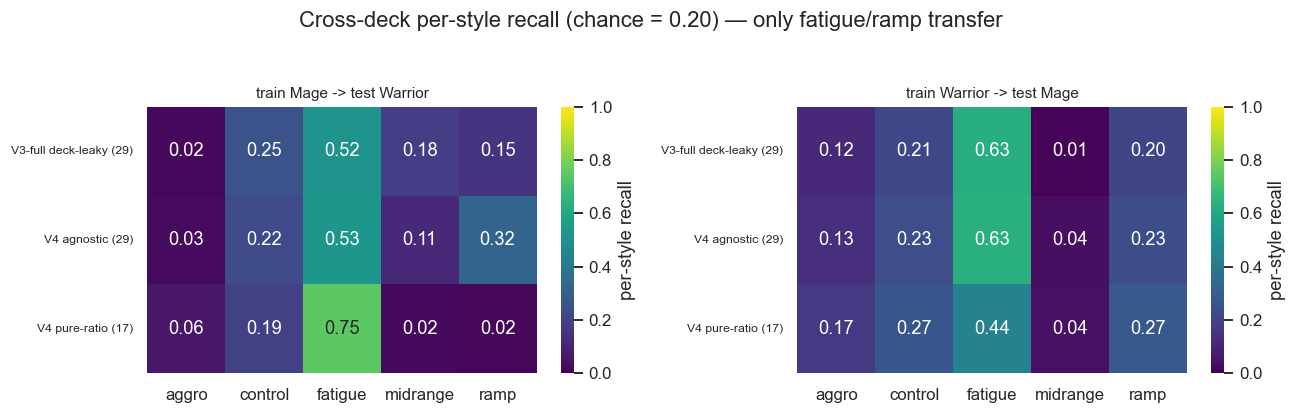

In [52]:
# R6 — §9b cross-deck per-style recall heatmaps (needs FEATURE_SETS/cross_rf/DA/DB from R5)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, (a, b, ttl) in zip(axes, [(DA, DB, "train Mage -> test Warrior"),
                                  (DB, DA, "train Warrior -> test Mage")]):
    rec = {name: cross_rf(feats, a, b)[1] for name, feats in FEATURE_SETS.items()}
    M = pd.DataFrame(rec).T[STYLE_ORDER]
    sns.heatmap(M, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=ax,
                cbar_kws={"label": "per-style recall"})
    ax.set_title(ttl, fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
fig.suptitle("Cross-deck per-style recall (chance = 0.20) — only fatigue/ramp transfer", y=1.04)
fig.tight_layout(); plt.show()

## R6b · Cross-deck aggregate accuracy vs games pooled

* **From:** V4 · **both** decks · agnostic features · source §9b (cell `v4xdeck_agg`, curve half).
* **Why a slide (the clincher):** pooling *fixed everything* within a deck (R3/R4) — but here,
  pooling N games into a cross-deck fingerprint barely moves the accuracy: the curves stay far below
  the 90% line even at N=120. That proves the cross-deck failure is **bias (deck entanglement), not
  variance (noise)** — you cannot average your way out of it. This is the motivation for R6c.
* **Depends on R5.**

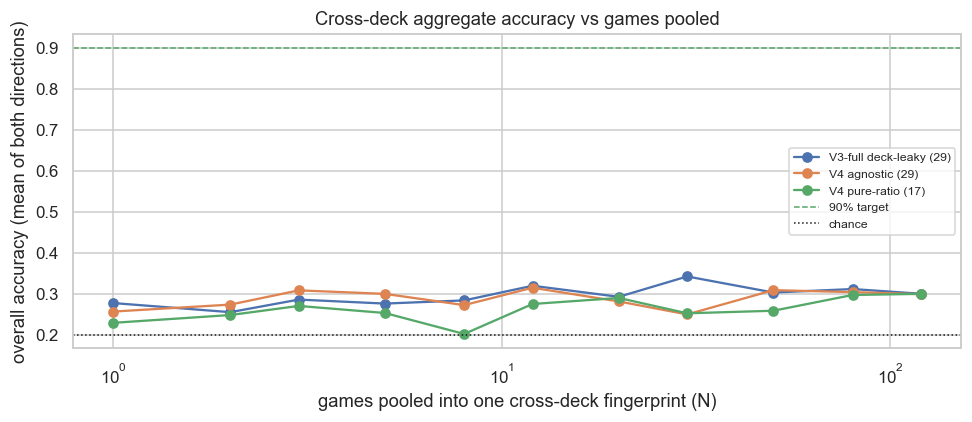

In [53]:
# R6b — §9b aggregate cross-deck accuracy vs games pooled (needs FEATURE_SETS/_xy/DA/DB from R5)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def cross_agg(feats, a, b, Ns=(1, 2, 3, 5, 8, 12, 20, 30, 50, 80, 120)):
    tr, te = games_all[games_all["deck"] == a], games_all[games_all["deck"] == b]
    Xtr, ytr = _xy(tr, feats); Xte, yte = _xy(te, feats, fill_from=tr)
    sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}; teby = {s: Xte[yte == s] for s in STYLE_ORDER}
    def fps(by, N, reps, seed):
        r = np.random.default_rng(seed); Xs, ys = [], []
        for si, s in enumerate(STYLE_ORDER):
            for _ in range(reps):
                Xs.append(by[s][r.integers(0, len(by[s]), N)].mean(0)); ys.append(si)
        return np.array(Xs), np.array(ys)
    out = {}
    for N in Ns:
        Xa, ya = fps(trby, N, 400, 10); Xb, yb = fps(teby, N, 400, 20)
        p = LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb)
        out[N] = (p == yb).mean()
    return pd.Series(out)

fig, ax = plt.subplots(figsize=(9, 4))
for name, feats in FEATURE_SETS.items():
    s = (cross_agg(feats, DA, DB) + cross_agg(feats, DB, DA)) / 2
    ax.plot(s.index, s.values, marker="o", label=name)
ax.axhline(0.90, color="g", ls="--", lw=1, label="90% target")
ax.axhline(0.20, color="k", ls=":", lw=1, label="chance")
ax.set_xscale("log"); ax.set_xlabel("games pooled into one cross-deck fingerprint (N)")
ax.set_ylabel("overall accuracy (mean of both directions)")
ax.set_title("Cross-deck aggregate accuracy vs games pooled")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## R7 · RF feature importance *(optional)*

* **From:** V2 · `RenoKazakusMage` · 11 V2 metrics · source §5b (cell `c9c7484e`).
* **Why a slide (support, not spine):** a supervised sanity check that the styles *are*
  separable given labels (RF 5-fold CV well above the 0.20 chance) and — the reason it's here —
  **which metrics carry the style**. The importance bars show the load spread across several tells
  (face-attack ratio, attacks/turn, cards-in-hand, game length…) rather than resting on any single
  spine. Left: RF confusion. Middle: feature importance. Right: LDA's best linear separation.

Random-forest 5-fold CV accuracy: 0.448   (chance = 0.20)


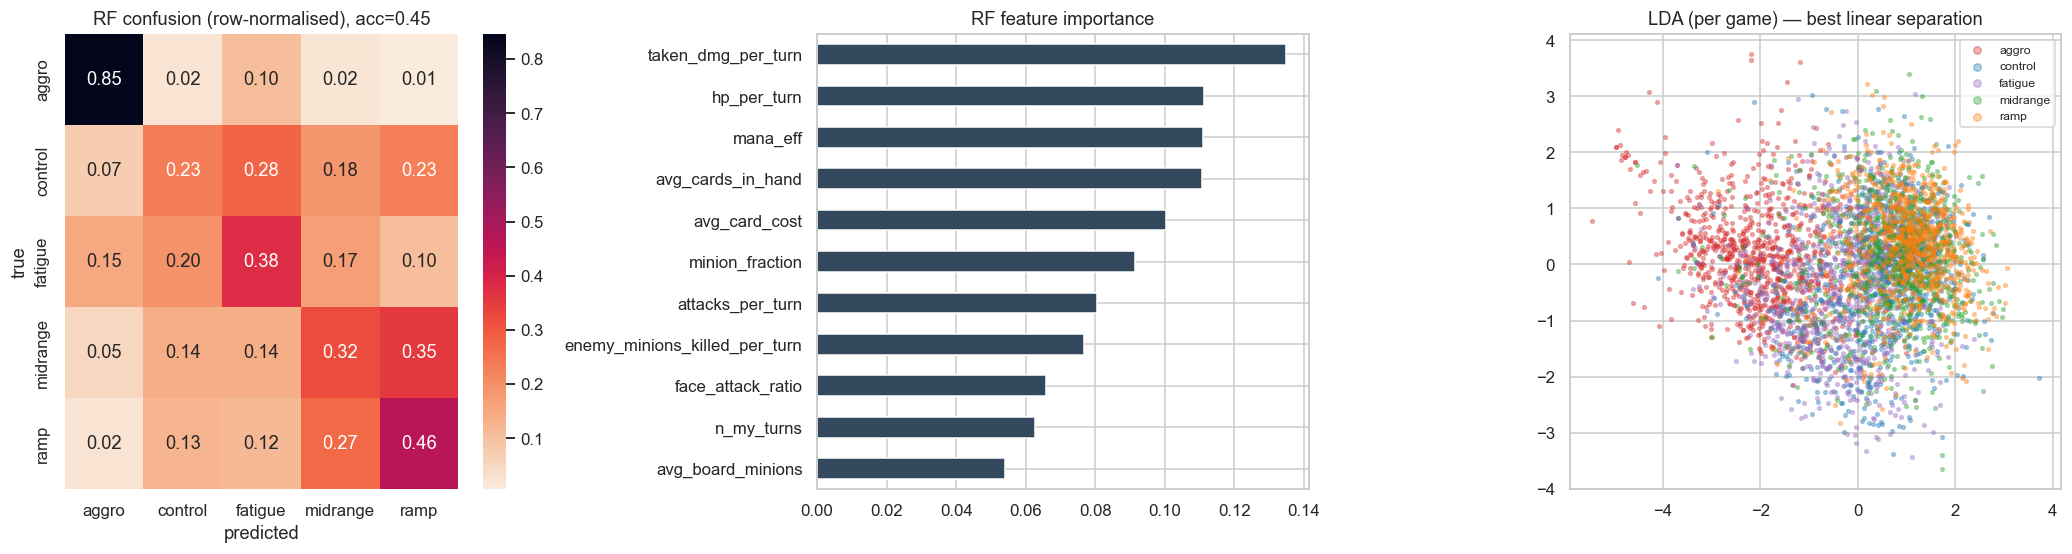

In [54]:
# R7 — §5b supervised check + RF feature importance (V2, Mage; uses X2/y2)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

rf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
pred = cross_val_predict(rf, X2, y2, cv=5)
acc = accuracy_score(y2, pred)
print(f"Random-forest 5-fold CV accuracy: {acc:.3f}   (chance = 0.20)")

rf.fit(X2, y2)
imp = pd.Series(rf.feature_importances_, index=FEATURES_V2).sort_values()
L = LinearDiscriminantAnalysis(n_components=2).fit(X2, y2).transform(X2)

fig, ax = plt.subplots(1, 3, figsize=(19, 5.2))
cm = confusion_matrix(y2, pred, labels=STYLE_ORDER, normalize="true")
sns.heatmap(pd.DataFrame(cm, index=STYLE_ORDER, columns=STYLE_ORDER), annot=True, fmt=".2f",
            cmap="rocket_r", ax=ax[0])
ax[0].set_title(f"RF confusion (row-normalised), acc={acc:.2f}"); ax[0].set_ylabel("true"); ax[0].set_xlabel("predicted")
imp.plot.barh(ax=ax[1], color="#34495e"); ax[1].set_title("RF feature importance")
for st in STYLE_ORDER:
    m = (y2 == st); ax[2].scatter(L[m, 0], L[m, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
ax[2].set_title("LDA (per game) — best linear separation"); ax[2].legend(fontsize=8, markerscale=2)
fig.tight_layout(); plt.show()

## R6c · Aggregated cross-deck: raw vs deck-normalised *(optional)*

* **From:** V4 · **both** decks · agnostic features · reviewer follow-up #3b (domain-shift correction).
* **Why a slide (future-work traction):** the *first partial fix* for the R5/R6/R6b collapse. Instead of
  raw feature values, express each game as **how far it deviates from the average player of its own deck**
  (per-deck z-score). That removes the deck-level bias and lifts aggregated cross-deck accuracy from
  ~0.30 toward ~0.45 — real traction, though deck-entanglement is not fully solved.
* **Left:** single-game raw vs deck-normalised (RF/LDA, both directions). **Right:** the same, aggregated vs N.

Single-game cross-deck accuracy (chance = 0.20):


,raw V4 agnostic,deck-normalised
RF M->W,0.242,0.278
RF W->M,0.254,0.327
LDA M->W,0.239,0.280
LDA W->M,0.291,0.356


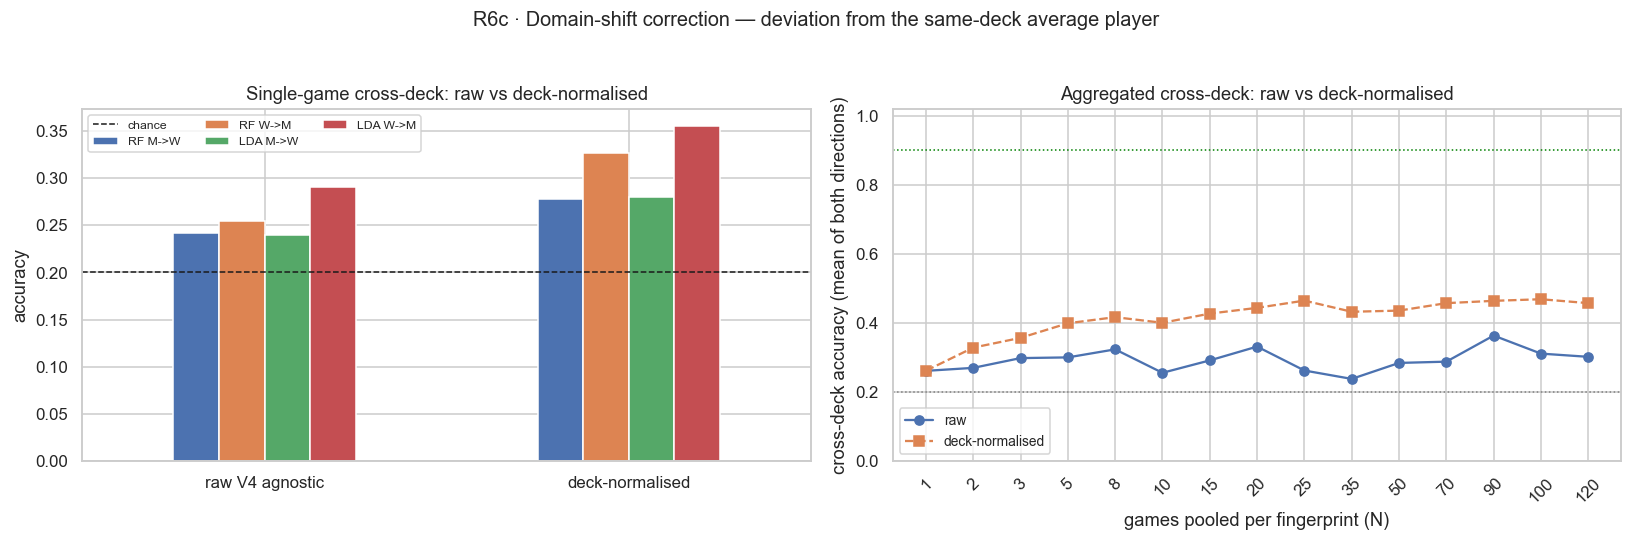

Read: per-deck z-scoring removes the deck's overall bias; aggregated cross-deck accuracy rises (~0.30 -> ~0.45), though deck-entanglement is not fully solved.


In [55]:
# R6c — reviewer #3b: domain-shift correction (standardise WITHIN each deck)  [both decks]
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

DA, DB   = "RenoKazakusMage", "AggroPirateWarrior"
XFEATS   = list(AGNOSTIC_FEATURES)

def deck_zscore(df, feats):
    g = df.copy()
    g[feats] = g[feats].fillna(g.groupby("deck")[feats].transform("median"))
    g[feats] = g.groupby("deck")[feats].transform(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
    return g

games_dz = deck_zscore(games_all, XFEATS)          # domain-corrected features

def cross_single(frame, a, b, feats, model="rf"):
    tr, te = frame[frame["deck"] == a], frame[frame["deck"] == b]
    med = tr[feats].median()                                   # impute from the TRAIN deck
    Xtr, Xte = tr[feats].fillna(med).values, te[feats].fillna(med).values
    ytr, yte = tr["style"].astype(str).values, te["style"].astype(str).values
    sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    clf = (RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
           if model == "rf" else LinearDiscriminantAnalysis())
    return accuracy_score(yte, clf.fit(Xtr, ytr).predict(Xte))

bars = {}
for label, frame in [("raw V4 agnostic", games_all), ("deck-normalised", games_dz)]:
    bars[label] = {"RF M->W":  cross_single(frame, DA, DB, XFEATS, "rf"),
                   "RF W->M":  cross_single(frame, DB, DA, XFEATS, "rf"),
                   "LDA M->W": cross_single(frame, DA, DB, XFEATS, "lda"),
                   "LDA W->M": cross_single(frame, DB, DA, XFEATS, "lda")}
barsdf = pd.DataFrame(bars)
print("Single-game cross-deck accuracy (chance = 0.20):"); display(barsdf.round(3))

def cross_agg(frame, a, b, feats, Ns=(1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120), reps=300):
    tr, te = frame[frame["deck"] == a], frame[frame["deck"] == b]
    med = tr[feats].median()                                   # impute from the TRAIN deck
    Xtr, Xte = tr[feats].fillna(med).values, te[feats].fillna(med).values
    ytr, yte = tr["style"].astype(str).values, te["style"].astype(str).values
    sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}; teby = {s: Xte[yte == s] for s in STYLE_ORDER}
    def fps(by, N, seed):
        r = np.random.default_rng(seed); Xs, ys = [], []
        for si, s in enumerate(STYLE_ORDER):
            for _ in range(reps):
                Xs.append(by[s][r.integers(0, len(by[s]), N)].mean(0)); ys.append(si)
        return np.array(Xs), np.array(ys)
    out = {}
    for N in Ns:
        Xa, ya = fps(trby, N, 10); Xb, yb = fps(teby, N, 20)
        out[N] = (LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb) == yb).mean()
    return pd.Series(out)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
barsdf.T.plot.bar(ax=ax[0]); ax[0].axhline(0.20, color="k", ls="--", lw=1, label="chance")
ax[0].set_title("Single-game cross-deck: raw vs deck-normalised"); ax[0].set_ylabel("accuracy")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0); ax[0].legend(fontsize=8, ncol=3)
for label, frame, ls in [("raw", games_all, "o-"), ("deck-normalised", games_dz, "s--")]:
    s = (cross_agg(frame, DA, DB, XFEATS) + cross_agg(frame, DB, DA, XFEATS)) / 2
    xs = range(len(s.index)); ax[1].plot(xs, s.values, ls, label=label)
ax[1].axhline(0.9, color="green", ls=":", lw=1); ax[1].axhline(0.2, color="gray", ls=":", lw=1)
ax[1].set_xticks(list(xs)); ax[1].set_xticklabels(s.index, rotation=45); ax[1].set_ylim(0, 1.02)
ax[1].set_xlabel("games pooled per fingerprint (N)")
ax[1].set_ylabel("cross-deck accuracy (mean of both directions)")
ax[1].set_title("Aggregated cross-deck: raw vs deck-normalised"); ax[1].legend(fontsize=9)
fig.suptitle("R6c · Domain-shift correction — deviation from the same-deck average player", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
print("Read: per-deck z-scoring removes the deck's overall bias; aggregated cross-deck accuracy "
      "rises (~0.30 -> ~0.45), though deck-entanglement is not fully solved.")

## Reading the deck end-to-end

1. **R2** — one game is ambiguous (ARI ≈ 0.09).
2. **R1 + R3** — a *player* (many games) is a sharp fingerprint (ARI → ≈ 0.99); R1 says what each looks like.
3. **R4** — so “how many games?” has a number: ~35 games → ~90% (richer V4-agnostic features).
4. **R5 + R6 + R6b** — but that fingerprint is **deck-entangled**: cross-deck accuracy collapses to ~0.24,
   only `fatigue`/`ramp` transfer, and pooling can't rescue it → it's bias, not noise.
5. **R6c** — first partial fix: deck-relative (per-deck z-scored) features lift aggregated cross-deck
   accuracy ~0.30 → ~0.45. Fully deck-agnostic play-style inference is the open future-work item.

## R2+R3 (combined) · KMeans-only: one game ambiguous → a pooled player is sharp

* **What & why:** a single-figure replacement that fuses R2 (one game) and R3 (pooled player) using
  **only the clustering result** — no PCA/t-SNE embeddings. PCA/t-SNE are just 2-D *projections* of the
  raw points (and t-SNE geometry can mislead); here every panel is the **same unsupervised KMeans(k=5)**
  and the *only* variable is **N** (games averaged into one fingerprint), so R2 and R3 become an
  apples-to-apples before/after.
* **Panels:** ① KMeans **ARI & silhouette vs N** (the trend) · ② KMeans confusion at **N=1** (one game,
  ARI ≈ 0.09) · ③ KMeans confusion at **N=120** (pooled player, ARI ≈ 0.99).
* **Note:** the original R2 and R3 cells above are kept as-is; this is an added, self-contained combined view.

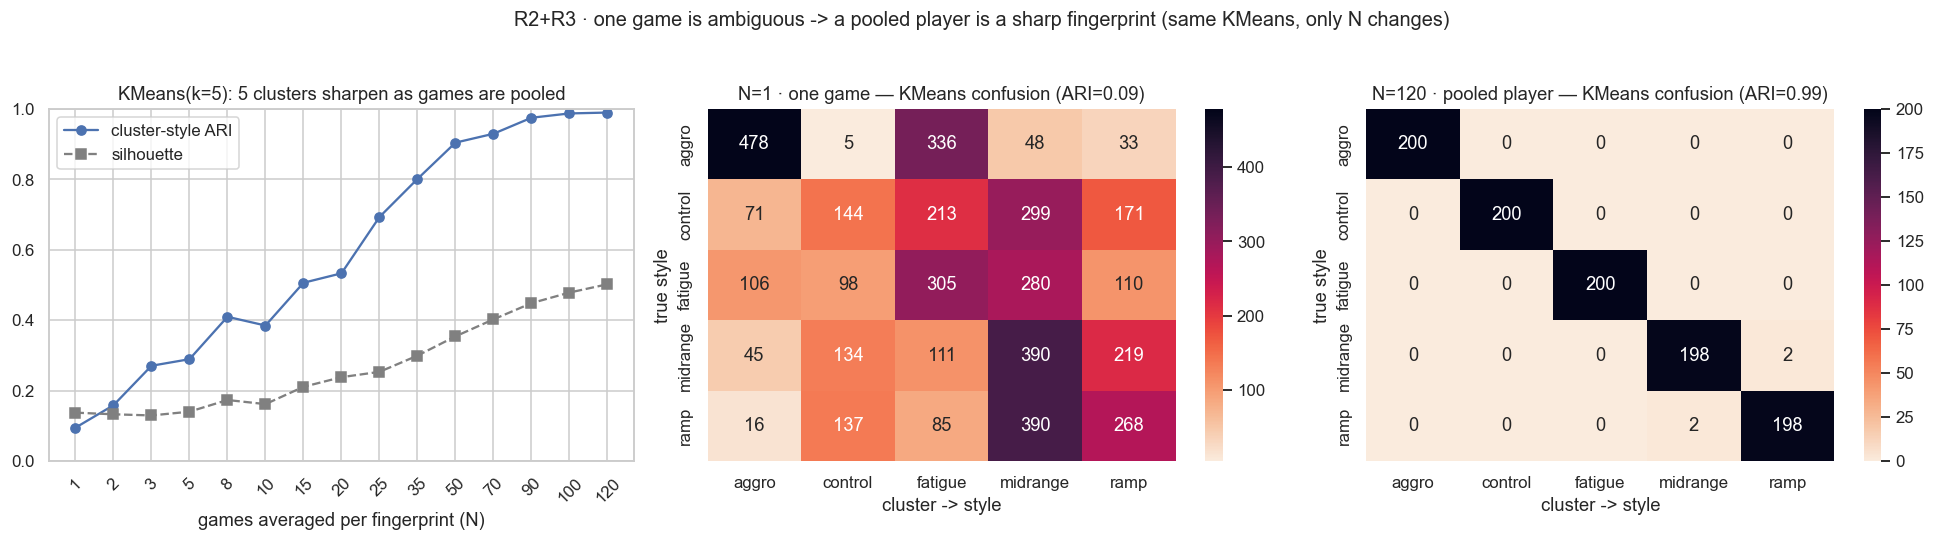

unsupervised KMeans(k=5) ARI:   N=1 -> 0.094    N=120 -> 0.990


In [56]:
# R2+R3 combined (KMeans only) — one game is ambiguous -> a pooled player is sharp.
# No PCA/t-SNE embeddings: every panel is the SAME unsupervised KMeans(k=5); the only
# thing that changes is N (games averaged into one fingerprint).
# Reuses X2 / y2 / cluster_confusion / STYLE_ORDER from the setup cell.
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

def _fingerprints(N, reps=200, seed=0):
    """reps 'players' per style, each = mean of N random games of that style."""
    rng = np.random.default_rng(seed)
    rows, lab = [], []
    for st in STYLE_ORDER:
        a = X2[y2 == st]
        for _ in range(reps):
            rows.append(a[rng.integers(0, len(a), N)].mean(axis=0)); lab.append(st)
    return np.array(rows), np.array(lab)

def _km_confusion(Xb, yb):
    lab = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)
    cm, _ = cluster_confusion(yb, lab)
    return cm, adjusted_rand_score(yb, lab)

# --- trend: KMeans(k=5) ARI & silhouette as a function of N ---
Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
aris, sils = [], []
for N in Ns:
    Xb, yb = (X2, y2) if N == 1 else _fingerprints(N)   # N=1 == the real per-game data (matches R2)
    lab = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)
    aris.append(adjusted_rand_score(yb, lab)); sils.append(silhouette_score(Xb, lab))

# --- the two extremes as KMeans confusion matrices ---
cm1,   ari1   = _km_confusion(X2, y2)                   # N=1   (one game)
Xb120, yb120  = _fingerprints(120)
cm120, ari120 = _km_confusion(Xb120, yb120)             # N=120 (pooled player)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
_xs = range(len(Ns))
ax[0].plot(_xs, aris, "o-", label="cluster-style ARI")
ax[0].plot(_xs, sils, "s--", color="gray", label="silhouette")
ax[0].set_xticks(list(_xs)); ax[0].set_xticklabels(Ns, rotation=45)
ax[0].set_xlabel("games averaged per fingerprint (N)"); ax[0].set_ylim(0, 1)
ax[0].set_title("KMeans(k=5): 5 clusters sharpen as games are pooled"); ax[0].legend()
sns.heatmap(cm1, annot=True, fmt="d", cmap="rocket_r", ax=ax[1])
ax[1].set_title(f"N=1 · one game — KMeans confusion (ARI={ari1:.2f})")
ax[1].set_ylabel("true style"); ax[1].set_xlabel("cluster -> style")
sns.heatmap(cm120, annot=True, fmt="d", cmap="rocket_r", ax=ax[2])
ax[2].set_title(f"N=120 · pooled player — KMeans confusion (ARI={ari120:.2f})")
ax[2].set_ylabel("true style"); ax[2].set_xlabel("cluster -> style")
fig.suptitle("R2+R3 · one game is ambiguous -> a pooled player is a sharp fingerprint "
             "(same KMeans, only N changes)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
print(f"unsupervised KMeans(k=5) ARI:   N=1 -> {ari1:.3f}    N=120 -> {ari120:.3f}")

### …and the same story as *clustering clouds* (like R3's middle panel)

The confusion matrices above say *how well* the clusters match the styles; this next cell **shows** it —
each point is one fingerprint (mean of N games), projected to 2-D by LDA and coloured by true style, so
you can literally see the single-game blob (N=1) resolve into five separated clouds (N=120). Depends on
`_fingerprints()` defined in the cell just above.

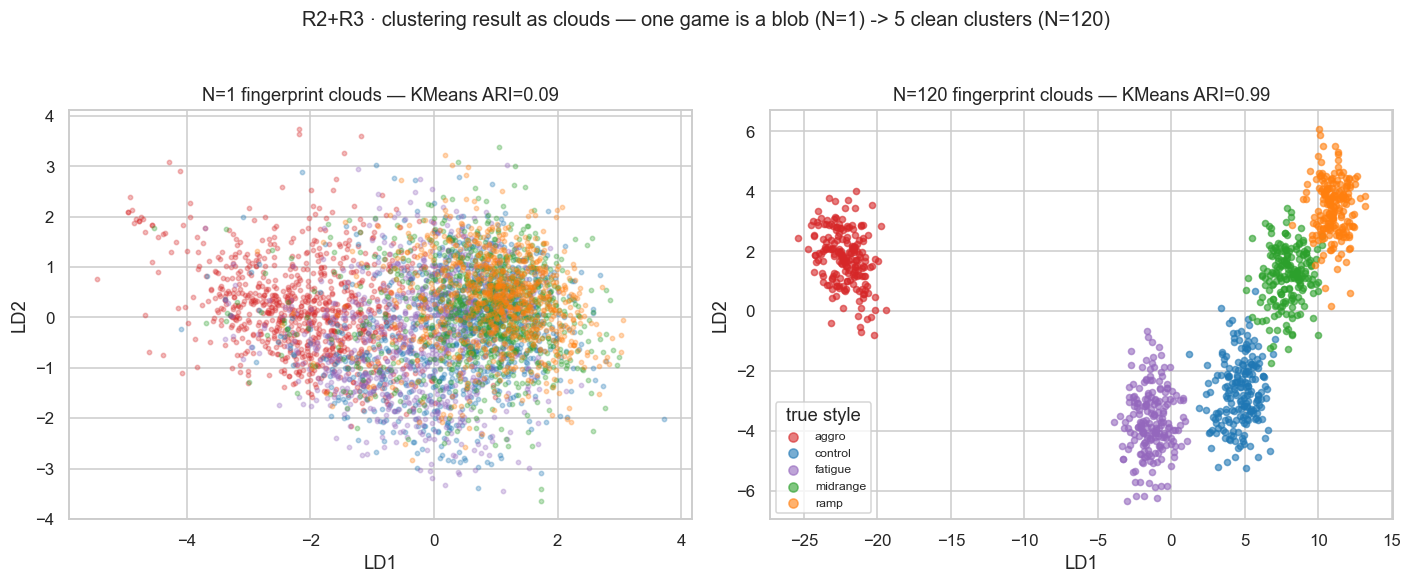

In [57]:
# R2+R3 (combined) · the clustering result AS CLOUDS — like the middle panel of R3.
# Each point is one fingerprint (mean of N games) projected to 2-D via LDA and coloured by
# TRUE style; the KMeans ARI in each title is how well unsupervised k=5 recovers those styles.
# Left  N=1   : the raw per-game points -> one tangled blob (ARI ~0.09).
# Right N=120 : pooled players -> five clean, separated clouds (ARI ~0.99).
# Reuses X2 / y2 / STYLE_ORDER / STYLE_COLORS from setup and _fingerprints() from the cell above.
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

fig, ax = plt.subplots(1, 2, figsize=(13, 5.4))
for j, (N, Xb, yb) in enumerate([(1, X2, y2), (120, *_fingerprints(120))]):
    L   = LinearDiscriminantAnalysis(n_components=2).fit(Xb, yb).transform(Xb)   # 2-D view
    lab = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)                   # the clustering
    ari = adjusted_rand_score(yb, lab)
    for st in STYLE_ORDER:
        m = (yb == st)
        ax[j].scatter(L[m, 0], L[m, 1], s=(8 if N == 1 else 16),
                      alpha=(0.30 if N == 1 else 0.6), color=STYLE_COLORS[st], label=st)
    ax[j].set_title(f"N={N} fingerprint clouds — KMeans ARI={ari:.2f}")
    ax[j].set_xlabel("LD1"); ax[j].set_ylabel("LD2")
ax[1].legend(fontsize=8, markerscale=1.5, title="true style")
fig.suptitle("R2+R3 · clustering result as clouds — one game is a blob (N=1) -> 5 clean clusters (N=120)",
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

## COMPARE · unsupervised vs supervised on the *same* metric (ARI)

You asked for one common yardstick so the two figures above are comparable. The R2+R3 figure is
**unsupervised** (KMeans, scored by ARI); R4 is **supervised** (LDA, scored by accuracy). Here both are
scored by **ARI vs the true styles**, on the **same held-out test fingerprints** — the only difference is
whether the model saw labels while fitting. (ARI works for a classifier too: it just measures agreement
between two labelings, and is invariant to how the clusters are numbered.)

* **Solid = supervised LDA, dashed = unsupervised KMeans**; blue = 11 V2 metrics, red = 29 V4-agnostic features.
* **Read it:** supervised leads at small N (labels help most when each fingerprint is noisy) and the richer
  V4-agnostic features lift it further; by N≈100 the gap closes as pooling alone makes the styles separable.
  *(Note: the unsupervised curve clusters the test set directly, so at large N it can even edge out the
  held-out supervised curve — a known quirk of comparing in-sample clustering to out-of-sample prediction.)*
* Nothing above was deleted; this is an added, self-contained comparison cell.

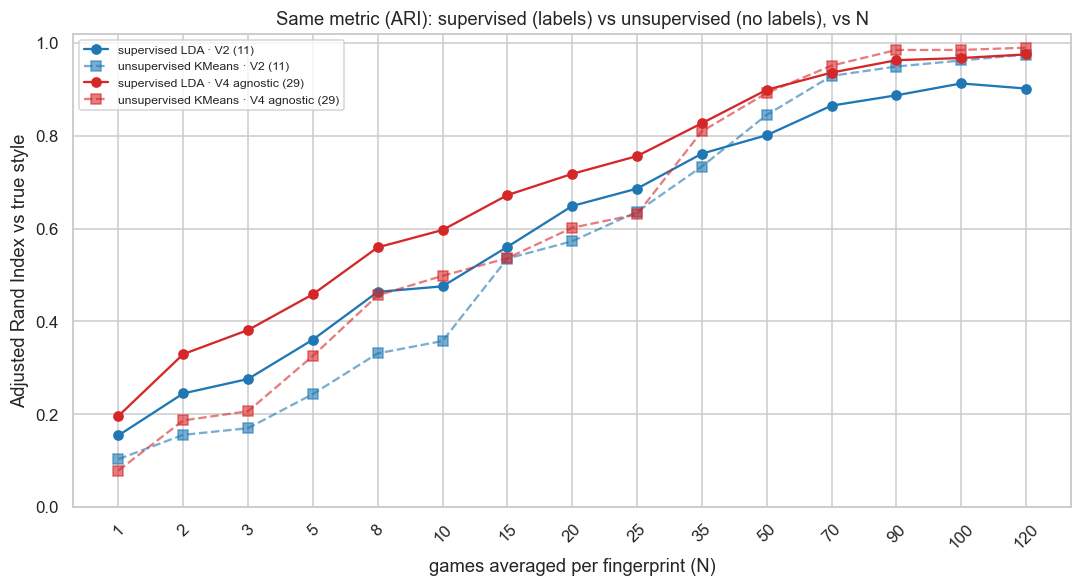

          V2 (11):  supervised ARI  N=1 0.15 -> N=120 0.90   |   unsupervised ARI  N=1 0.10 -> N=120 0.98
 V4 agnostic (29):  supervised ARI  N=1 0.20 -> N=120 0.98   |   unsupervised ARI  N=1 0.08 -> N=120 0.99


In [58]:
# COMPARE · unsupervised vs supervised on ONE metric (ARI vs N) — apples-to-apples.
# Both methods are scored by Adjusted Rand Index against the TRUE styles, on the SAME held-out
# TEST fingerprints; the ONLY difference is whether the model saw labels while fitting:
#   * unsupervised = KMeans(k=5).fit_predict on the test fingerprints (ARI ignores cluster-id)
#   * supervised   = LDA trained on TRAIN fingerprints, predicting those test fingerprints
# Shown for both feature sets so it bridges the two figures above:
#   V2 (11)  -> the R2+R3 unsupervised story ;  V4 agnostic (29) -> the R4 supervised story.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import adjusted_rand_score

def _split_by_style(df, feats, seed=1):
    """50/50 disjoint train/test split within each style; standardised trby/teby dicts."""
    rng = np.random.default_rng(seed)
    G = df.copy(); G[feats] = G[feats].fillna(G[feats].median())
    tr_idx, te_idx = [], []
    for st in STYLE_ORDER:
        idx = G.index[G["style"] == st].to_numpy().copy(); rng.shuffle(idx)
        h = len(idx) // 2; tr_idx += list(idx[:h]); te_idx += list(idx[h:])
    tr, te = G.loc[tr_idx], G.loc[te_idx]
    sc = StandardScaler().fit(tr[feats].values)
    Xtr, Xte = sc.transform(tr[feats].values), sc.transform(te[feats].values)
    ytr, yte = tr["style"].astype(str).values, te["style"].astype(str).values
    return ({s: Xtr[ytr == s] for s in STYLE_ORDER},
            {s: Xte[yte == s] for s in STYLE_ORDER})

def _fps(by, N, reps=300, seed=0):
    r = np.random.default_rng(seed); Xs, ys = [], []
    for s in STYLE_ORDER:
        a = by[s]
        for _ in range(reps):
            Xs.append(a[r.integers(0, len(a), N)].mean(0)); ys.append(s)
    return np.array(Xs), np.array(ys)

Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
curves = {}
for tag, feats in [("V2 (11)", FEATURES_V2), ("V4 agnostic (29)", FEATURES_V4)]:
    trby, teby = _split_by_style(games_mage, feats)
    uns, sup = [], []
    for N in Ns:
        Xte, yte = _fps(teby, N, seed=20)                       # SAME held-out test fingerprints
        Xtr, ytr = _fps(trby, N, seed=10)
        pred = LinearDiscriminantAnalysis().fit(Xtr, ytr).predict(Xte)   # supervised (uses labels)
        sup.append(adjusted_rand_score(yte, pred))
        clab = KMeans(5, n_init=10, random_state=0).fit_predict(Xte)     # unsupervised (no labels)
        uns.append(adjusted_rand_score(yte, clab))
    curves[tag] = (uns, sup)

fig, ax = plt.subplots(figsize=(10, 5.5))
_xs = range(len(Ns))
col = {"V2 (11)": "#1f77b4", "V4 agnostic (29)": "#d62728"}
for tag, (uns, sup) in curves.items():
    c = col[tag]
    ax.plot(_xs, sup, "o-",  color=c, label=f"supervised LDA · {tag}")
    ax.plot(_xs, uns, "s--", color=c, alpha=0.6, label=f"unsupervised KMeans · {tag}")
ax.set_xticks(list(_xs)); ax.set_xticklabels(Ns, rotation=45); ax.set_ylim(0, 1.02)
ax.set_xlabel("games averaged per fingerprint (N)")
ax.set_ylabel("Adjusted Rand Index vs true style")
ax.set_title("Same metric (ARI): supervised (labels) vs unsupervised (no labels), vs N")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()
for tag, (uns, sup) in curves.items():
    print(f"{tag:>17}:  supervised ARI  N=1 {sup[0]:.2f} -> N=120 {sup[-1]:.2f}   |   "
          f"unsupervised ARI  N=1 {uns[0]:.2f} -> N=120 {uns[-1]:.2f}")

## PER-STYLE · unsupervised broken out by play-style (like R4's supervised panel)

The aggregate ARI curve above hides *which* styles are easy or hard. Here the **unsupervised** KMeans is
shown **per class**, exactly like R4's supervised panel: 5 coloured style curves + a black `overall`
dashed line, accuracy vs N. KMeans still clusters **without labels** — but since the true labels exist,
at the end each cluster is aligned to a style (Hungarian match, the notebook's `cluster_confusion`) and
that gives a per-style accuracy directly comparable to the supervised model.

* **Left = supervised LDA, right = unsupervised KMeans**, same V4-agnostic held-out fingerprints and
  same per-style colours.
* **Read it:** the *shape* is the same — `aggro`/`fatigue` are easy early, `control`/`midrange`/`ramp`
  need pooling — but the unsupervised curves start lower and need more games (esp. `control`/`midrange`)
  before they catch up near N≈35–50. The dotted lines mark chance (0.20) and the 90% target.
* Nothing above was deleted; this is an added, self-contained per-style view.

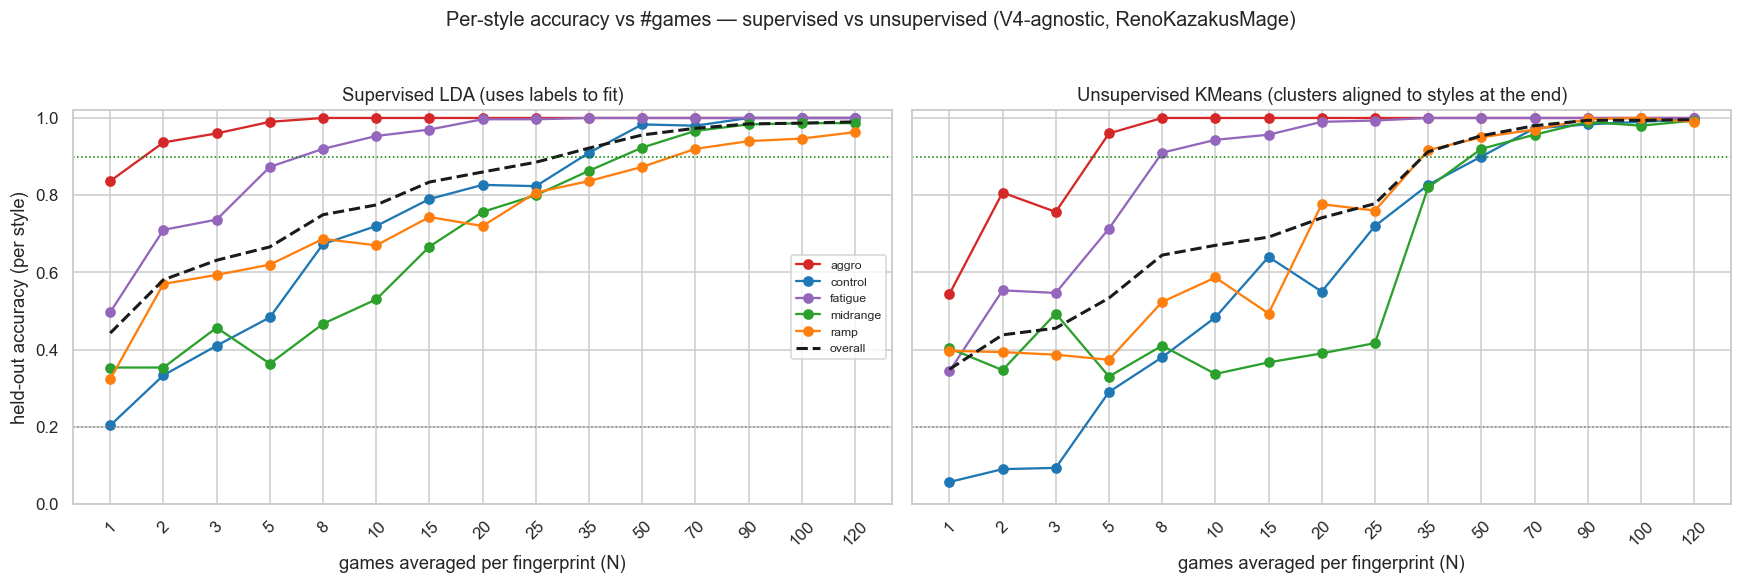

N to reach per-style >= 90%:
  supervised  : aggro: 2 | control: 35 | fatigue: 8 | midrange: 50 | ramp: 70  || overall: 35
  unsupervised: aggro: 5 | control: 50 | fatigue: 8 | midrange: 50 | ramp: 35  || overall: 35


In [59]:
# PER-STYLE accuracy vs #games — supervised LDA vs unsupervised KMeans (like R4's panel 1).
# Unsupervised has no labels while clustering, but the labels DO exist, so at the end we align
# each cluster to a style (Hungarian, via cluster_confusion from setup) and then read off the
# same per-style accuracy the supervised model reports. Same V4-agnostic held-out fingerprints
# and same styling (STYLE_COLORS) as R4, so the two panels are directly comparable.
# Reuses _split_by_style / _fps from the COMPARE cell above, and cluster_confusion / STYLE_* from setup.
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
trby, teby = _split_by_style(games_mage, FEATURES_V4)     # V4 agnostic, held-out split (matches R4)

sup_rows, uns_rows = [], []
for N in Ns:
    Xtr, ytr = _fps(trby, N, seed=10)
    Xte, yte = _fps(teby, N, seed=20)                     # SAME test fingerprints for both methods
    # supervised: LDA uses the labels while fitting
    pred = LinearDiscriminantAnalysis().fit(Xtr, ytr).predict(Xte)
    # unsupervised: KMeans with NO labels, then align clusters -> styles (labels used only here, at the end)
    _, mapped = cluster_confusion(yte, KMeans(5, n_init=10, random_state=0).fit_predict(Xte))
    sr = {"overall": (pred == yte).mean()}
    ur = {"overall": (mapped == yte).mean()}
    for s in STYLE_ORDER:
        m = (yte == s)
        sr[s] = (pred[m] == s).mean()
        ur[s] = (mapped[m] == s).mean()
    sup_rows.append(sr); uns_rows.append(ur)
sup = pd.DataFrame(sup_rows, index=Ns); uns = pd.DataFrame(uns_rows, index=Ns)

fig, ax = plt.subplots(1, 2, figsize=(16, 5.4), sharey=True)
for j, (df, ttl) in enumerate([(sup, "Supervised LDA (uses labels to fit)"),
                               (uns, "Unsupervised KMeans (clusters aligned to styles at the end)")]):
    _xs = range(len(Ns))
    for s in STYLE_ORDER:
        ax[j].plot(_xs, df[s], "o-", color=STYLE_COLORS[s], label=s)
    ax[j].plot(_xs, df["overall"], "k--", lw=2, label="overall")
    ax[j].axhline(0.2, color="gray", ls=":", lw=1); ax[j].axhline(0.9, color="green", ls=":", lw=1)
    ax[j].set_xticks(list(_xs)); ax[j].set_xticklabels(Ns, rotation=45); ax[j].set_ylim(0, 1.02)
    ax[j].set_xlabel("games averaged per fingerprint (N)"); ax[j].set_title(ttl)
ax[0].set_ylabel("held-out accuracy (per style)"); ax[0].legend(fontsize=8)
fig.suptitle("Per-style accuracy vs #games — supervised vs unsupervised (V4-agnostic, RenoKazakusMage)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

def _firstN(df, col, thr=0.90):
    hit = df.index[df[col] >= thr]; return int(hit[0]) if len(hit) else f">{Ns[-1]}"
print("N to reach per-style >= 90%:")
print("  supervised  : " + " | ".join(f"{s}: {_firstN(sup, s)}" for s in STYLE_ORDER) + f"  || overall: {_firstN(sup, 'overall')}")
print("  unsupervised: " + " | ".join(f"{s}: {_firstN(uns, s)}" for s in STYLE_ORDER) + f"  || overall: {_firstN(uns, 'overall')}")

## SUPERVISED · everything on ARI — per-style (one-vs-rest) + overall

You asked to score **all of supervised learning with ARI** (to match the unsupervised figures), as a new
cell. ARI is a whole-partition metric, so per style we use a **one-vs-rest ARI** (that style vs the rest)
and add the **overall multiclass ARI** as the dashed line — the ARI analogue of R4's supervised accuracy
panel, same V4-agnostic held-out fingerprints and same per-style colours.

* **Read it:** identical *shape* to R4 (aggro is a near-giveaway, midrange is the hardest), but on the ARI
  scale — 0 = chance-level agreement, 1 = perfect. overall multiclass ARI reaches ~0.90 at N≈50.
* Nothing above was deleted; this is an added, supervised-only ARI view. Reuses `_split_by_style` / `_fps`
  from the COMPARE cell above and `STYLE_*` from setup.

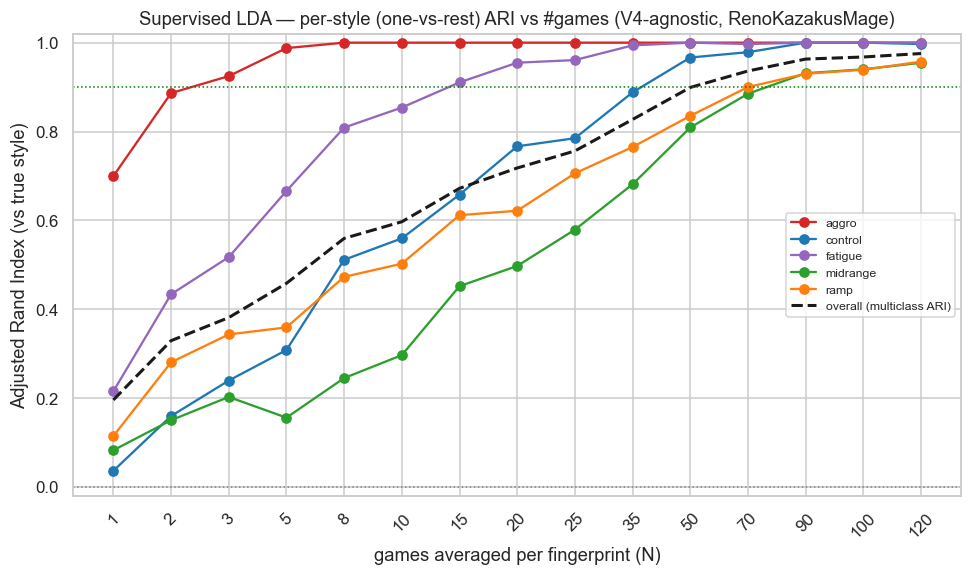

Supervised ARI — smallest N to reach >= 0.90:
  per style:  aggro: 3 | control: 50 | fatigue: 15 | midrange: 90 | ramp: 70
  overall (multiclass ARI): N = 70


In [60]:
# SUPERVISED learning scored entirely by ARI (per-style one-vs-rest + overall), like R4's panel.
# ARI is a partition metric, so 'per style' = one-vs-rest ARI (style s vs the rest); 'overall' =
# multiclass ARI. Same V4-agnostic held-out fingerprints / styling as R4, so it lines up with it.
# Reuses _split_by_style / _fps from the COMPARE cell above, and STYLE_ORDER/STYLE_COLORS from setup.
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import adjusted_rand_score

Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
trby, teby = _split_by_style(games_mage, FEATURES_V4)     # V4 agnostic, held-out split (matches R4)

rows = []
for N in Ns:
    Xtr, ytr = _fps(trby, N, seed=10)
    Xte, yte = _fps(teby, N, seed=20)
    pred = LinearDiscriminantAnalysis().fit(Xtr, ytr).predict(Xte)   # supervised: LDA uses labels to fit
    row = {"overall": adjusted_rand_score(yte, pred)}               # overall multiclass ARI
    for s in STYLE_ORDER:
        row[s] = adjusted_rand_score(yte == s, pred == s)           # per-style one-vs-rest ARI
    rows.append(row)
sup_ari = pd.DataFrame(rows, index=Ns)

fig, ax = plt.subplots(figsize=(9, 5.4))
_xs = range(len(Ns))
for s in STYLE_ORDER:
    ax.plot(_xs, sup_ari[s], "o-", color=STYLE_COLORS[s], label=s)
ax.plot(_xs, sup_ari["overall"], "k--", lw=2, label="overall (multiclass ARI)")
ax.axhline(0.0, color="gray", ls=":", lw=1); ax.axhline(0.9, color="green", ls=":", lw=1)
ax.set_xticks(list(_xs)); ax.set_xticklabels(Ns, rotation=45); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("games averaged per fingerprint (N)")
ax.set_ylabel("Adjusted Rand Index (vs true style)")
ax.set_title("Supervised LDA — per-style (one-vs-rest) ARI vs #games (V4-agnostic, RenoKazakusMage)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

def _firstN(col, thr=0.90):
    hit = sup_ari.index[sup_ari[col] >= thr]; return int(hit[0]) if len(hit) else f">{Ns[-1]}"
print("Supervised ARI — smallest N to reach >= 0.90:")
print("  per style:  " + " | ".join(f"{s}: {_firstN(s)}" for s in STYLE_ORDER))
print(f"  overall (multiclass ARI): N = {_firstN('overall')}")

## PER-STYLE (ARI) · supervised vs unsupervised — the ARI twin of the accuracy panel

Same two-panel per-style comparison as the accuracy figure above, but scored with **ARI** instead of
accuracy (as requested). Per style = **one-vs-rest ARI** (that style vs the rest); the dashed line is the
**overall multiclass ARI**. Same V4-agnostic held-out fingerprints, same per-style colours, so it lines up
panel-for-panel with the accuracy version.

* **Left = supervised LDA, right = unsupervised KMeans** (clusters aligned to styles at the end via
  `cluster_confusion`, so the labels are used only for scoring, not for clustering).
* **Read it:** identical ordering to the accuracy panel (aggro easy, midrange hardest; unsupervised lags
  supervised until N≈35–50) but on the chance-adjusted ARI scale (0 = chance, 1 = perfect).
* The accuracy panel above is untouched; this is an added ARI twin. Reuses `_split_by_style` / `_fps` from
  the COMPARE cell and `cluster_confusion` / `STYLE_*` from setup.

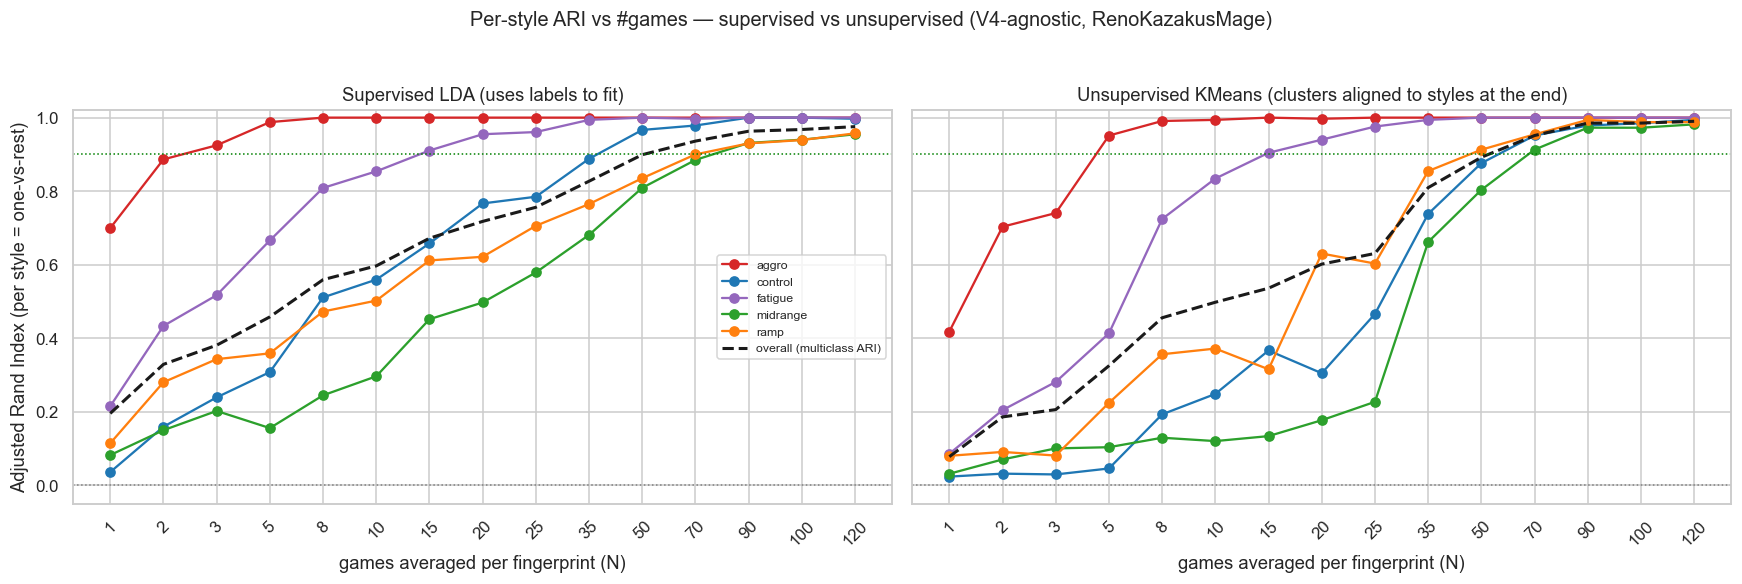

N to reach per-style ARI >= 0.90:
  supervised  : aggro: 3 | control: 50 | fatigue: 15 | midrange: 90 | ramp: 70  || overall: 70
  unsupervised: aggro: 5 | control: 70 | fatigue: 15 | midrange: 70 | ramp: 50  || overall: 70


In [61]:
# PER-STYLE ARI vs #games — supervised vs unsupervised (ARI twin of the accuracy panel above).
# ARI is a partition metric, so 'per style' = one-vs-rest ARI (style s vs the rest); 'overall' =
# multiclass ARI (mapping-invariant, so KMeans needs no alignment for the overall value).
# Unsupervised clusters WITHOUT labels; cluster_confusion aligns clusters->styles only to score per-style.
# Reuses _split_by_style / _fps from the COMPARE cell and cluster_confusion / STYLE_* from setup.
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import adjusted_rand_score

Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
trby, teby = _split_by_style(games_mage, FEATURES_V4)     # V4 agnostic, held-out split (matches R4)

sup_rows, uns_rows = [], []
for N in Ns:
    Xtr, ytr = _fps(trby, N, seed=10)
    Xte, yte = _fps(teby, N, seed=20)                     # SAME test fingerprints for both methods
    pred = LinearDiscriminantAnalysis().fit(Xtr, ytr).predict(Xte)          # supervised (uses labels)
    clab = KMeans(5, n_init=10, random_state=0).fit_predict(Xte)            # unsupervised (no labels)
    _, mapped = cluster_confusion(yte, clab)                               # align clusters -> styles (scoring only)
    sr = {"overall": adjusted_rand_score(yte, pred)}                       # overall multiclass ARI
    ur = {"overall": adjusted_rand_score(yte, clab)}                       # (mapping-invariant)
    for s in STYLE_ORDER:
        sr[s] = adjusted_rand_score(yte == s, pred == s)                   # per-style one-vs-rest ARI
        ur[s] = adjusted_rand_score(yte == s, mapped == s)
    sup_rows.append(sr); uns_rows.append(ur)
sup = pd.DataFrame(sup_rows, index=Ns); uns = pd.DataFrame(uns_rows, index=Ns)

fig, ax = plt.subplots(1, 2, figsize=(16, 5.4), sharey=True)
for j, (df, ttl) in enumerate([(sup, "Supervised LDA (uses labels to fit)"),
                               (uns, "Unsupervised KMeans (clusters aligned to styles at the end)")]):
    _xs = range(len(Ns))
    for s in STYLE_ORDER:
        ax[j].plot(_xs, df[s], "o-", color=STYLE_COLORS[s], label=s)
    ax[j].plot(_xs, df["overall"], "k--", lw=2, label="overall (multiclass ARI)")
    ax[j].axhline(0.0, color="gray", ls=":", lw=1); ax[j].axhline(0.9, color="green", ls=":", lw=1)
    ax[j].set_xticks(list(_xs)); ax[j].set_xticklabels(Ns, rotation=45); ax[j].set_ylim(-0.05, 1.02)
    ax[j].set_xlabel("games averaged per fingerprint (N)"); ax[j].set_title(ttl)
ax[0].set_ylabel("Adjusted Rand Index (per style = one-vs-rest)"); ax[0].legend(fontsize=8)
fig.suptitle("Per-style ARI vs #games — supervised vs unsupervised (V4-agnostic, RenoKazakusMage)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

def _firstN(df, col, thr=0.90):
    hit = df.index[df[col] >= thr]; return int(hit[0]) if len(hit) else f">{Ns[-1]}"
print("N to reach per-style ARI >= 0.90:")
print("  supervised  : " + " | ".join(f"{s}: {_firstN(sup, s)}" for s in STYLE_ORDER) + f"  || overall: {_firstN(sup, 'overall')}")
print("  unsupervised: " + " | ".join(f"{s}: {_firstN(uns, s)}" for s in STYLE_ORDER) + f"  || overall: {_firstN(uns, 'overall')}")

# RANDOMFOREST TWINS · every LDA analysis re-done with RandomForest

Below, each figure in this deck that used **LDA as a classifier** is reproduced with
**`RandomForestClassifier`** swapped in for `LinearDiscriminantAnalysis`; everything else (the
KMeans in the combined figures, the nearest-centroid reference, the feature sets, the held-out
splits) is unchanged. The originals above are untouched — these are additive twins.

**Not convertible (LDA used only as a 2-D projection, not a classifier):** R3's fingerprint clouds,
R7's LDA scatter, and the "clustering result as clouds" cell all use `LinearDiscriminantAnalysis(...).transform(...)`
to *embed* points in 2-D. RandomForest has **no `.transform()`** / linear axes, so there is no
RF equivalent of those embeddings — they are intentionally not reproduced here.

RF settings: `n_estimators=200, random_state=0, n_jobs=-1`; fingerprint `reps` slightly reduced vs the
LDA cells to keep runtime snappy (RF is heavier than LDA). Depends only on the `setup` cell.

In [62]:
# RANDOMFOREST TWINS · shared setup — self-contained given only the `setup` cell.
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

def make_rf():
    return RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)

NS_RF = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]

def rf_split(df, feats, seed=1):
    """50/50 disjoint per-style split -> standardised (Xtr, ytr, Xte, yte)."""
    rng = np.random.default_rng(seed)
    G = df.copy(); G[feats] = G[feats].fillna(G[feats].median())
    tr_idx, te_idx = [], []
    for st in STYLE_ORDER:
        idx = G.index[G["style"] == st].to_numpy().copy(); rng.shuffle(idx)
        h = len(idx) // 2; tr_idx += list(idx[:h]); te_idx += list(idx[h:])
    tr, te = G.loc[tr_idx], G.loc[te_idx]
    sc = StandardScaler().fit(tr[feats].values)
    return (sc.transform(tr[feats].values), tr["style"].astype(str).values,
            sc.transform(te[feats].values), te["style"].astype(str).values)

def rf_fps(X, y, N, reps=250, seed=0):
    """reps fingerprints per style, each = mean of N random games of that style."""
    r = np.random.default_rng(seed); Xs, ys = [], []
    for s in STYLE_ORDER:
        a = X[y == s]
        for _ in range(reps):
            Xs.append(a[r.integers(0, len(a), N)].mean(0)); ys.append(s)
    return np.array(Xs), np.array(ys)

# feature sets + cross-deck helpers (same definitions as R5), self-contained
RF_V3_FULL = list(V2_METRICS) + list(TRAJ_METRICS) + list(A_FEATURES)
RF_FEATURE_SETS = {
    f"V3-full deck-leaky ({len(RF_V3_FULL)})": RF_V3_FULL,
    f"V4 agnostic ({len(AGNOSTIC_FEATURES)})": list(AGNOSTIC_FEATURES),
    f"V4 pure-ratio ({len(RATIO_FEATURES)})":  list(RATIO_FEATURES),
}
DA_RF, DB_RF = "RenoKazakusMage", "AggroPirateWarrior"

def rf_deck_zscore(df, feats):
    g = df.copy()
    g[feats] = g[feats].fillna(g.groupby("deck")[feats].transform("median"))
    g[feats] = g.groupby("deck")[feats].transform(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
    return g

print("RF-twins setup ready: make_rf(), rf_split(), rf_fps(), RF_FEATURE_SETS, rf_deck_zscore()")

RF-twins setup ready: make_rf(), rf_split(), rf_fps(), RF_FEATURE_SETS, rf_deck_zscore()


## R4-RF · accuracy vs #games (per style) — RandomForest instead of LDA

The R4 supervised classifier is now a **RandomForest** (V4-agnostic, Mage), same 3 panels: accuracy-vs-N
per style · per-style accuracy heatmap · single-game confusion. RF reaches **~90% overall around N ≈ 35**
and ~0.49 on a single game — essentially matching the LDA version, with the same easy/hard ordering
(`aggro`/`fatigue` easy, `midrange` hardest).

RF — smallest N to reach accuracy:
  overall >= 80%: N = 20
  overall >= 90%: N = 35
  per style >= 90%:  aggro: 2 | control: 50 | fatigue: 8 | midrange: 70 | ramp: 120
single-game accuracy: 0.486  (chance 0.20)


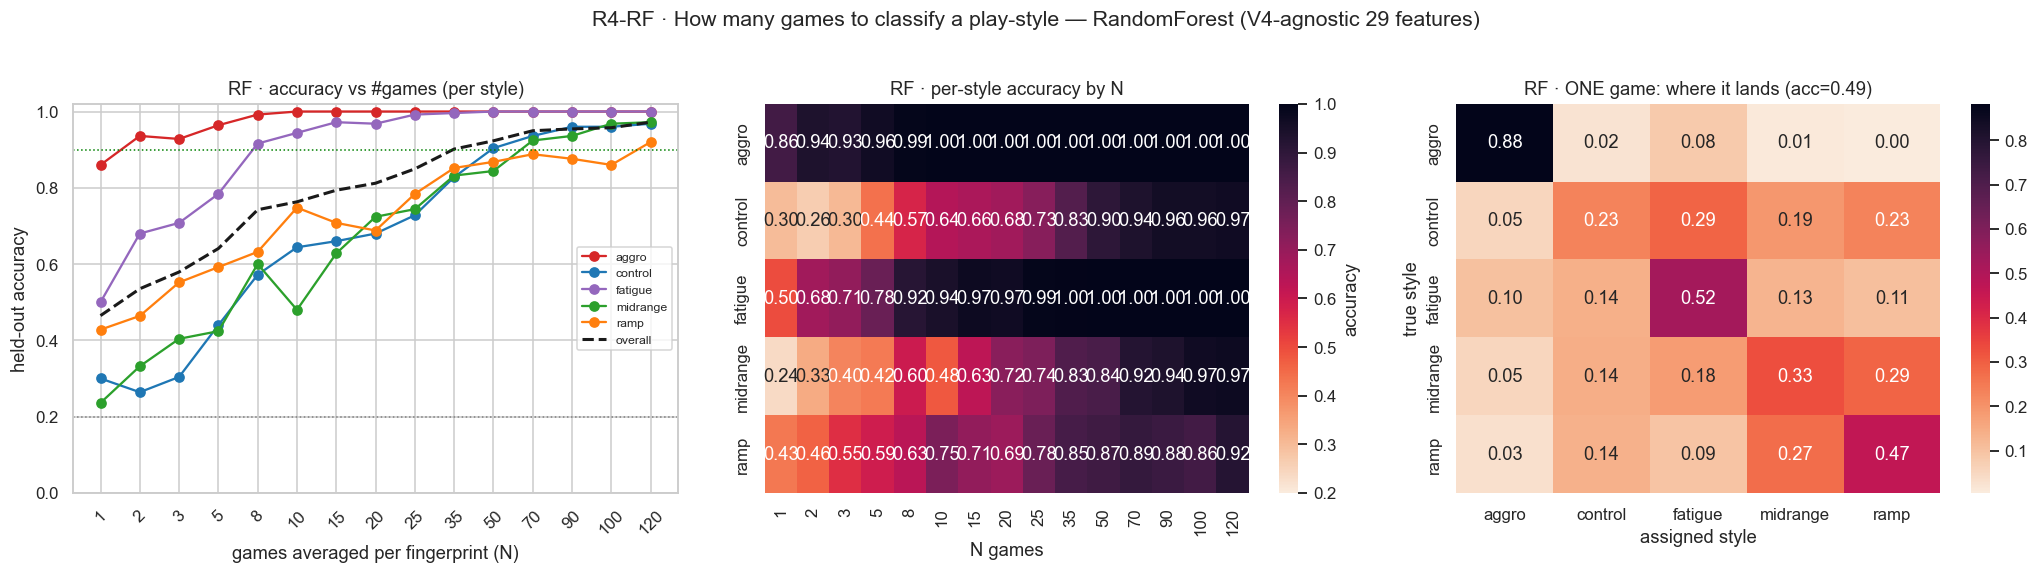

In [63]:
# R4-RF — R4 with RandomForest instead of LDA (V4 agnostic, Mage).
Xtr, ytr, Xte, yte = rf_split(games_mage, FEATURES_V4)
rows = []
for N in NS_RF:
    Xa, ya = rf_fps(Xtr, ytr, N, seed=10)
    Xb, yb = rf_fps(Xte, yte, N, seed=20)
    pred = make_rf().fit(Xa, ya).predict(Xb)
    row = {"N": N, "overall": (pred == yb).mean()}
    for s in STYLE_ORDER:
        row[s] = (pred[yb == s] == s).mean()
    rows.append(row)
acc = pd.DataFrame(rows).set_index("N")
cm1 = confusion_matrix(yte, make_rf().fit(Xtr, ytr).predict(Xte), labels=STYLE_ORDER, normalize="true")

def _fN(col, thr):
    hit = acc.index[acc[col] >= thr]; return int(hit[0]) if len(hit) else f">{NS_RF[-1]}"
print("RF — smallest N to reach accuracy:")
for thr in (0.80, 0.90):
    print(f"  overall >= {thr:.0%}: N = {_fN('overall', thr)}")
print("  per style >= 90%:  " + " | ".join(f"{s}: {_fN(s, 0.90)}" for s in STYLE_ORDER))
print(f"single-game accuracy: {np.trace(cm1)/5:.3f}  (chance 0.20)")

fig, ax = plt.subplots(1, 3, figsize=(19, 5.3))
_xs = range(len(acc.index))
for s in STYLE_ORDER:
    ax[0].plot(_xs, acc[s], "o-", color=STYLE_COLORS[s], label=s)
ax[0].plot(_xs, acc["overall"], "k--", lw=2, label="overall")
ax[0].axhline(0.2, color="gray", ls=":", lw=1); ax[0].axhline(0.9, color="green", ls=":", lw=1)
ax[0].set_xticks(list(_xs)); ax[0].set_xticklabels(acc.index, rotation=45); ax[0].set_ylim(0, 1.02)
ax[0].set_xlabel("games averaged per fingerprint (N)"); ax[0].set_ylabel("held-out accuracy")
ax[0].set_title("RF · accuracy vs #games (per style)"); ax[0].legend(fontsize=8)
sns.heatmap(acc[STYLE_ORDER].T, annot=True, fmt=".2f", cmap="rocket_r", vmin=0.2, vmax=1.0, ax=ax[1],
            cbar_kws={"label": "accuracy"})
ax[1].set_title("RF · per-style accuracy by N"); ax[1].set_xlabel("N games"); ax[1].set_ylabel("")
sns.heatmap(pd.DataFrame(cm1, index=STYLE_ORDER, columns=STYLE_ORDER), annot=True, fmt=".2f",
            cmap="rocket_r", ax=ax[2])
ax[2].set_title(f"RF · ONE game: where it lands (acc={np.trace(cm1)/5:.2f})")
ax[2].set_ylabel("true style"); ax[2].set_xlabel("assigned style")
fig.suptitle("R4-RF · How many games to classify a play-style — RandomForest (V4-agnostic 29 features)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## COMPARE-RF · ARI vs N — supervised **RandomForest** vs unsupervised KMeans

The COMPARE ARI figure with the supervised model swapped to RandomForest (KMeans unchanged), both feature
sets. Same held-out test fingerprints, scored by ARI vs true style.

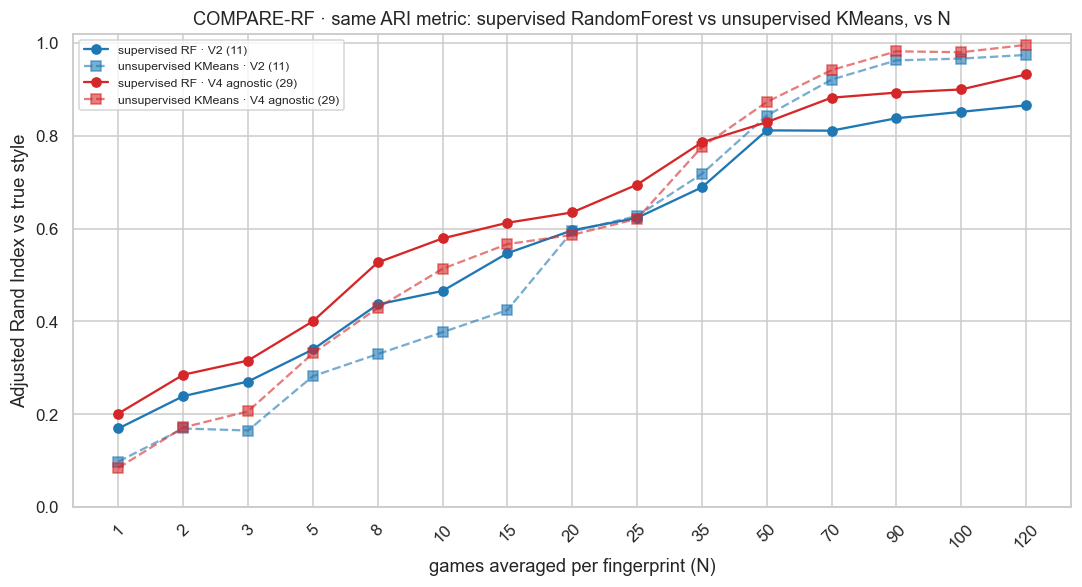

          V2 (11):  supervised RF ARI  N=1 0.17 -> N=120 0.87   |   unsupervised ARI  N=1 0.10 -> N=120 0.97
 V4 agnostic (29):  supervised RF ARI  N=1 0.20 -> N=120 0.93   |   unsupervised ARI  N=1 0.08 -> N=120 1.00


In [64]:
# COMPARE-RF — supervised model = RandomForest (unsupervised KMeans unchanged); ARI vs N, both feature sets.
curves = {}
for tag, feats in [("V2 (11)", FEATURES_V2), ("V4 agnostic (29)", FEATURES_V4)]:
    Xtr, ytr, Xte, yte = rf_split(games_mage, feats)
    uns, sup = [], []
    for N in NS_RF:
        Xa, ya = rf_fps(Xtr, ytr, N, seed=10)
        Xb, yb = rf_fps(Xte, yte, N, seed=20)
        sup.append(adjusted_rand_score(yb, make_rf().fit(Xa, ya).predict(Xb)))
        uns.append(adjusted_rand_score(yb, KMeans(5, n_init=10, random_state=0).fit_predict(Xb)))
    curves[tag] = (uns, sup)

fig, ax = plt.subplots(figsize=(10, 5.5))
_xs = range(len(NS_RF))
col = {"V2 (11)": "#1f77b4", "V4 agnostic (29)": "#d62728"}
for tag, (uns, sup) in curves.items():
    c = col[tag]
    ax.plot(_xs, sup, "o-",  color=c, label=f"supervised RF · {tag}")
    ax.plot(_xs, uns, "s--", color=c, alpha=0.6, label=f"unsupervised KMeans · {tag}")
ax.set_xticks(list(_xs)); ax.set_xticklabels(NS_RF, rotation=45); ax.set_ylim(0, 1.02)
ax.set_xlabel("games averaged per fingerprint (N)"); ax.set_ylabel("Adjusted Rand Index vs true style")
ax.set_title("COMPARE-RF · same ARI metric: supervised RandomForest vs unsupervised KMeans, vs N")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()
for tag, (uns, sup) in curves.items():
    print(f"{tag:>17}:  supervised RF ARI  N=1 {sup[0]:.2f} -> N=120 {sup[-1]:.2f}   |   "
          f"unsupervised ARI  N=1 {uns[0]:.2f} -> N=120 {uns[-1]:.2f}")

## perstyle-acc-RF · per-style **accuracy** vs N — RandomForest vs unsupervised KMeans

The per-style accuracy panel with the supervised side as RandomForest (unsupervised KMeans clusters aligned
to styles at the end via `cluster_confusion`). Same V4-agnostic fingerprints and per-style colours.

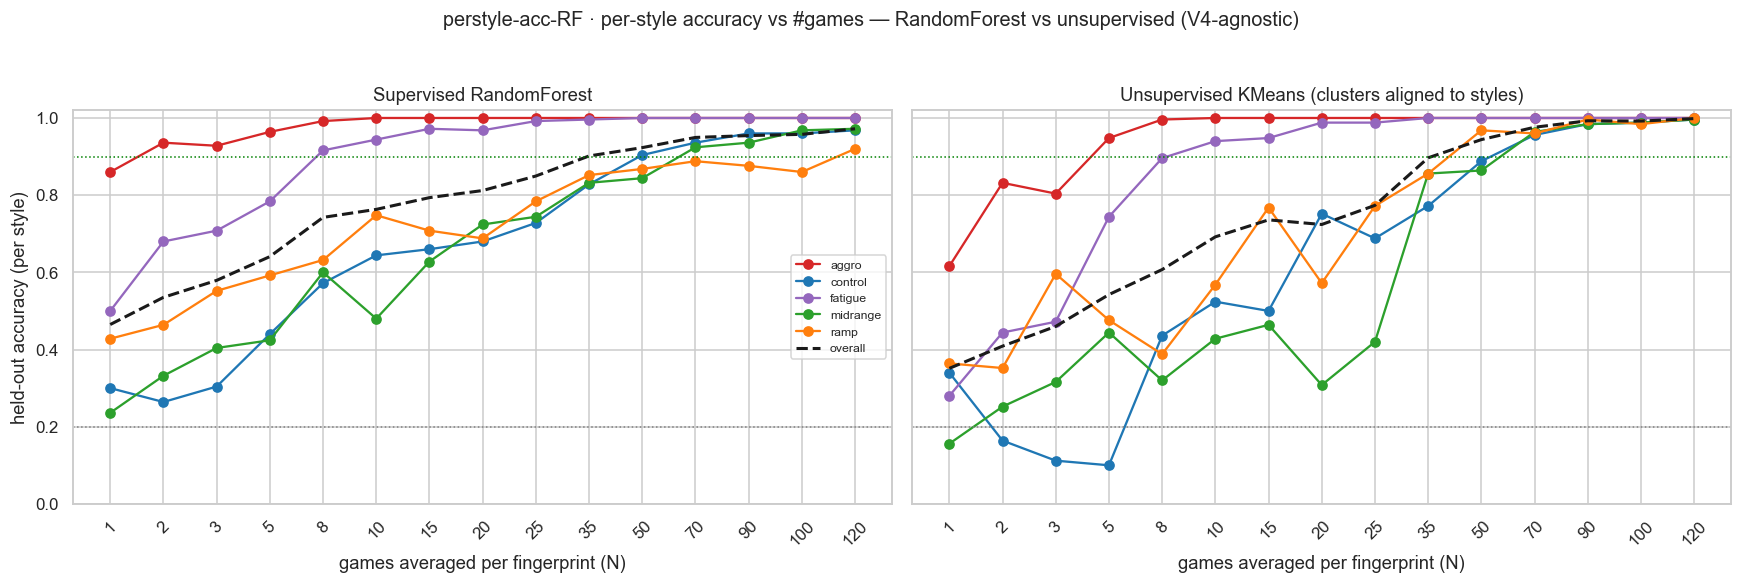

In [65]:
# perstyle-acc-RF — per-style ACCURACY vs N: supervised RandomForest vs unsupervised KMeans (V4 agnostic).
Xtr, ytr, Xte, yte = rf_split(games_mage, FEATURES_V4)
sup_rows, uns_rows = [], []
for N in NS_RF:
    Xa, ya = rf_fps(Xtr, ytr, N, seed=10)
    Xb, yb = rf_fps(Xte, yte, N, seed=20)
    pred = make_rf().fit(Xa, ya).predict(Xb)
    _, mapped = cluster_confusion(yb, KMeans(5, n_init=10, random_state=0).fit_predict(Xb))
    sr = {"overall": (pred == yb).mean()}; ur = {"overall": (mapped == yb).mean()}
    for s in STYLE_ORDER:
        sr[s] = (pred[yb == s] == s).mean(); ur[s] = (mapped[yb == s] == s).mean()
    sup_rows.append(sr); uns_rows.append(ur)
sup = pd.DataFrame(sup_rows, index=NS_RF); uns = pd.DataFrame(uns_rows, index=NS_RF)

fig, ax = plt.subplots(1, 2, figsize=(16, 5.4), sharey=True)
for j, (df, ttl) in enumerate([(sup, "Supervised RandomForest"),
                               (uns, "Unsupervised KMeans (clusters aligned to styles)")]):
    _xs = range(len(NS_RF))
    for s in STYLE_ORDER:
        ax[j].plot(_xs, df[s], "o-", color=STYLE_COLORS[s], label=s)
    ax[j].plot(_xs, df["overall"], "k--", lw=2, label="overall")
    ax[j].axhline(0.2, color="gray", ls=":", lw=1); ax[j].axhline(0.9, color="green", ls=":", lw=1)
    ax[j].set_xticks(list(_xs)); ax[j].set_xticklabels(NS_RF, rotation=45); ax[j].set_ylim(0, 1.02)
    ax[j].set_xlabel("games averaged per fingerprint (N)"); ax[j].set_title(ttl)
ax[0].set_ylabel("held-out accuracy (per style)"); ax[0].legend(fontsize=8)
fig.suptitle("perstyle-acc-RF · per-style accuracy vs #games — RandomForest vs unsupervised (V4-agnostic)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

## sup-ari-RF · supervised **RandomForest** scored by ARI (per-style one-vs-rest + overall)

The supervised-ARI cell with RandomForest instead of LDA: per style = one-vs-rest ARI, dashed = overall
multiclass ARI. V4-agnostic, Mage.

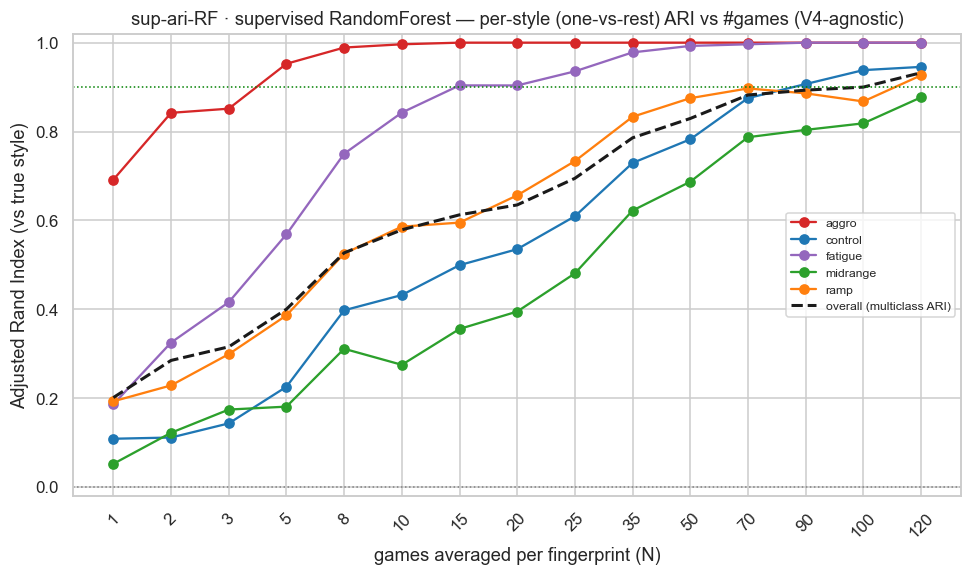

In [66]:
# sup-ari-RF — supervised RandomForest scored by ARI, per-style (one-vs-rest) + overall multiclass.
Xtr, ytr, Xte, yte = rf_split(games_mage, FEATURES_V4)
rows = []
for N in NS_RF:
    Xa, ya = rf_fps(Xtr, ytr, N, seed=10)
    Xb, yb = rf_fps(Xte, yte, N, seed=20)
    pred = make_rf().fit(Xa, ya).predict(Xb)
    row = {"overall": adjusted_rand_score(yb, pred)}
    for s in STYLE_ORDER:
        row[s] = adjusted_rand_score(yb == s, pred == s)
    rows.append(row)
ari = pd.DataFrame(rows, index=NS_RF)

fig, ax = plt.subplots(figsize=(9, 5.4))
_xs = range(len(NS_RF))
for s in STYLE_ORDER:
    ax.plot(_xs, ari[s], "o-", color=STYLE_COLORS[s], label=s)
ax.plot(_xs, ari["overall"], "k--", lw=2, label="overall (multiclass ARI)")
ax.axhline(0.0, color="gray", ls=":", lw=1); ax.axhline(0.9, color="green", ls=":", lw=1)
ax.set_xticks(list(_xs)); ax.set_xticklabels(NS_RF, rotation=45); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("games averaged per fingerprint (N)"); ax.set_ylabel("Adjusted Rand Index (vs true style)")
ax.set_title("sup-ari-RF · supervised RandomForest — per-style (one-vs-rest) ARI vs #games (V4-agnostic)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## perstyle-ari-RF · per-style **ARI** vs N — RandomForest vs unsupervised KMeans

The ARI twin of the per-style panel with the supervised side as RandomForest. Per style = one-vs-rest ARI,
dashed = overall multiclass ARI.

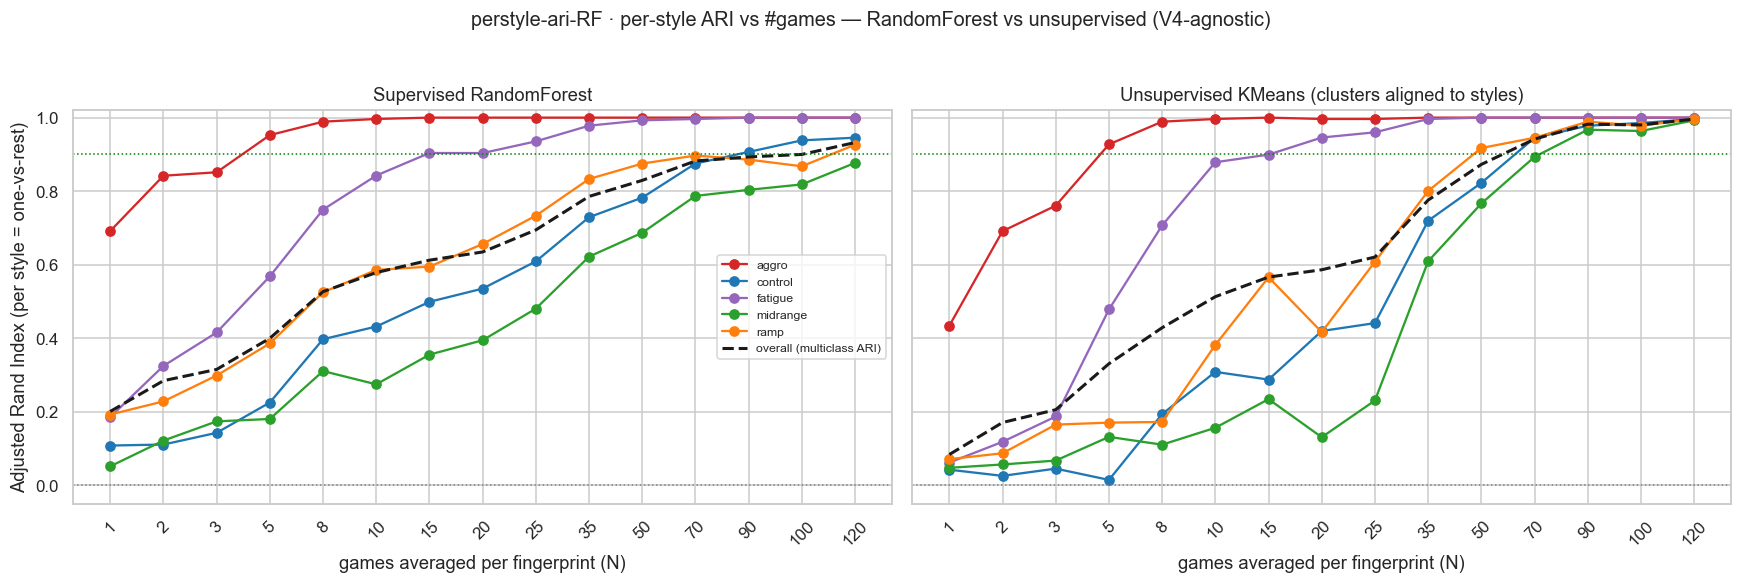

In [67]:
# perstyle-ari-RF — per-style ARI vs N: supervised RandomForest vs unsupervised KMeans (V4 agnostic).
Xtr, ytr, Xte, yte = rf_split(games_mage, FEATURES_V4)
sup_rows, uns_rows = [], []
for N in NS_RF:
    Xa, ya = rf_fps(Xtr, ytr, N, seed=10)
    Xb, yb = rf_fps(Xte, yte, N, seed=20)
    pred = make_rf().fit(Xa, ya).predict(Xb)
    clab = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)
    _, mapped = cluster_confusion(yb, clab)
    sr = {"overall": adjusted_rand_score(yb, pred)}
    ur = {"overall": adjusted_rand_score(yb, clab)}
    for s in STYLE_ORDER:
        sr[s] = adjusted_rand_score(yb == s, pred == s)
        ur[s] = adjusted_rand_score(yb == s, mapped == s)
    sup_rows.append(sr); uns_rows.append(ur)
sup = pd.DataFrame(sup_rows, index=NS_RF); uns = pd.DataFrame(uns_rows, index=NS_RF)

fig, ax = plt.subplots(1, 2, figsize=(16, 5.4), sharey=True)
for j, (df, ttl) in enumerate([(sup, "Supervised RandomForest"),
                               (uns, "Unsupervised KMeans (clusters aligned to styles)")]):
    _xs = range(len(NS_RF))
    for s in STYLE_ORDER:
        ax[j].plot(_xs, df[s], "o-", color=STYLE_COLORS[s], label=s)
    ax[j].plot(_xs, df["overall"], "k--", lw=2, label="overall (multiclass ARI)")
    ax[j].axhline(0.0, color="gray", ls=":", lw=1); ax[j].axhline(0.9, color="green", ls=":", lw=1)
    ax[j].set_xticks(list(_xs)); ax[j].set_xticklabels(NS_RF, rotation=45); ax[j].set_ylim(-0.05, 1.02)
    ax[j].set_xlabel("games averaged per fingerprint (N)"); ax[j].set_title(ttl)
ax[0].set_ylabel("Adjusted Rand Index (per style = one-vs-rest)"); ax[0].legend(fontsize=8)
fig.suptitle("perstyle-ari-RF · per-style ARI vs #games — RandomForest vs unsupervised (V4-agnostic)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

## R6b-RF · cross-deck aggregate accuracy vs games pooled — RandomForest

R6b with RandomForest instead of LDA (mean of both directions, all three feature sets). Same message: pooling
barely moves cross-deck accuracy — it stays far below the 90% line even at N=120 (bias, not noise).

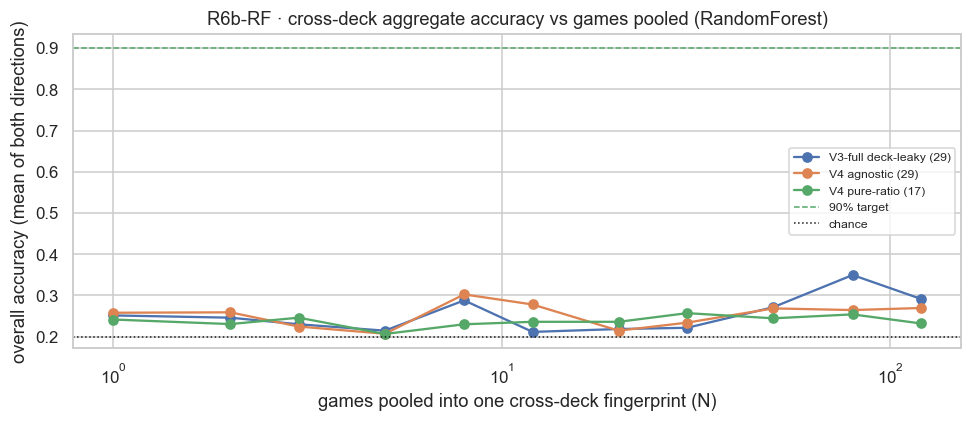

In [68]:
# R6b-RF — cross-deck aggregate accuracy vs games pooled, RandomForest instead of LDA (mean of both directions).
def rf_cross_agg(feats, a, b, Ns=(1, 2, 3, 5, 8, 12, 20, 30, 50, 80, 120)):
    tr, te = games_all[games_all["deck"] == a], games_all[games_all["deck"] == b]
    med = tr[feats].median()
    Xtr, Xte = tr[feats].fillna(med).values, te[feats].fillna(med).values
    ytr, yte = tr["style"].astype(str).values, te["style"].astype(str).values
    sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    out = {}
    for N in Ns:
        Xa, ya = rf_fps(Xtr, ytr, N, reps=200, seed=10)
        Xb, yb = rf_fps(Xte, yte, N, reps=200, seed=20)
        out[N] = (make_rf().fit(Xa, ya).predict(Xb) == yb).mean()
    return pd.Series(out)

fig, ax = plt.subplots(figsize=(9, 4))
for name, feats in RF_FEATURE_SETS.items():
    s = (rf_cross_agg(feats, DA_RF, DB_RF) + rf_cross_agg(feats, DB_RF, DA_RF)) / 2
    ax.plot(s.index, s.values, marker="o", label=name)
ax.axhline(0.90, color="g", ls="--", lw=1, label="90% target")
ax.axhline(0.20, color="k", ls=":", lw=1, label="chance")
ax.set_xscale("log"); ax.set_xlabel("games pooled into one cross-deck fingerprint (N)")
ax.set_ylabel("overall accuracy (mean of both directions)")
ax.set_title("R6b-RF · cross-deck aggregate accuracy vs games pooled (RandomForest)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## R6c-RF · domain-shift correction (raw vs deck-normalised) — RandomForest

R6c with RandomForest for both the single-game bars and the aggregated curve (the LDA branch of R6c becomes
RF). Per-deck z-scoring lifts single-game cross-deck accuracy (~0.24 → ~0.28–0.32), but aggregated cross-deck
accuracy stays low — same partial-fix story as the LDA version.

Single-game cross-deck accuracy (RandomForest, chance = 0.20):


,raw V4 agnostic,deck-normalised
RF M->W,0.241,0.277
RF W->M,0.256,0.323


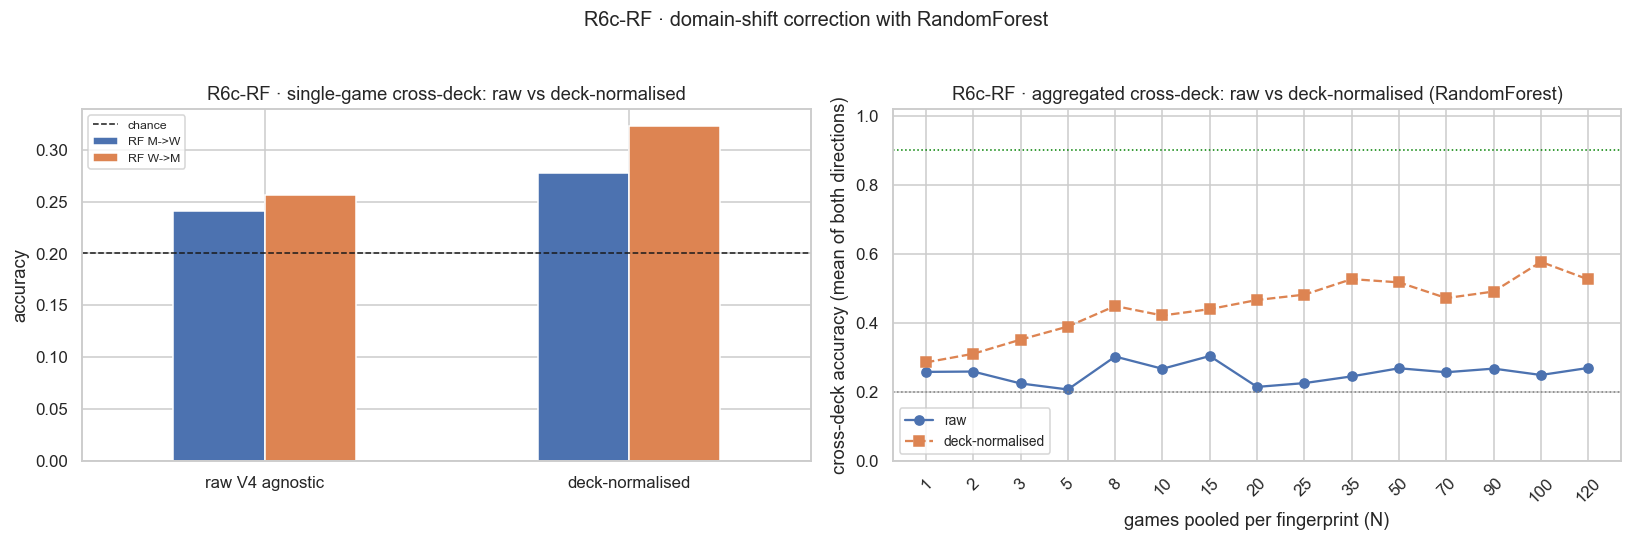

In [69]:
# R6c-RF — domain-shift correction with RandomForest (the LDA branches of R6c become RF).
XF = list(AGNOSTIC_FEATURES)
games_dz_rf = rf_deck_zscore(games_all, XF)

def rf_cross_single(frame, a, b, feats):
    tr, te = frame[frame["deck"] == a], frame[frame["deck"] == b]
    med = tr[feats].median()
    Xtr, Xte = tr[feats].fillna(med).values, te[feats].fillna(med).values
    ytr, yte = tr["style"].astype(str).values, te["style"].astype(str).values
    sc = StandardScaler().fit(Xtr)
    return (make_rf().fit(sc.transform(Xtr), ytr).predict(sc.transform(Xte)) == yte).mean()

bars = {}
for label, frame in [("raw V4 agnostic", games_all), ("deck-normalised", games_dz_rf)]:
    bars[label] = {"RF M->W": rf_cross_single(frame, DA_RF, DB_RF, XF),
                   "RF W->M": rf_cross_single(frame, DB_RF, DA_RF, XF)}
barsdf = pd.DataFrame(bars)
print("Single-game cross-deck accuracy (RandomForest, chance = 0.20):"); display(barsdf.round(3))

def rf_cross_agg2(frame, a, b, feats, Ns=(1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120)):
    tr, te = frame[frame["deck"] == a], frame[frame["deck"] == b]
    med = tr[feats].median()
    Xtr, Xte = tr[feats].fillna(med).values, te[feats].fillna(med).values
    ytr, yte = tr["style"].astype(str).values, te["style"].astype(str).values
    sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    out = {}
    for N in Ns:
        Xa, ya = rf_fps(Xtr, ytr, N, reps=200, seed=10)
        Xb, yb = rf_fps(Xte, yte, N, reps=200, seed=20)
        out[N] = (make_rf().fit(Xa, ya).predict(Xb) == yb).mean()
    return pd.Series(out)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
barsdf.T.plot.bar(ax=ax[0]); ax[0].axhline(0.20, color="k", ls="--", lw=1, label="chance")
ax[0].set_title("R6c-RF · single-game cross-deck: raw vs deck-normalised"); ax[0].set_ylabel("accuracy")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0); ax[0].legend(fontsize=8)
for label, frame, ls in [("raw", games_all, "o-"), ("deck-normalised", games_dz_rf, "s--")]:
    s = (rf_cross_agg2(frame, DA_RF, DB_RF, XF) + rf_cross_agg2(frame, DB_RF, DA_RF, XF)) / 2
    xs = range(len(s.index)); ax[1].plot(xs, s.values, ls, label=label)
ax[1].axhline(0.9, color="green", ls=":", lw=1); ax[1].axhline(0.2, color="gray", ls=":", lw=1)
ax[1].set_xticks(list(xs)); ax[1].set_xticklabels(s.index, rotation=45); ax[1].set_ylim(0, 1.02)
ax[1].set_xlabel("games pooled per fingerprint (N)"); ax[1].set_ylabel("cross-deck accuracy (mean of both directions)")
ax[1].set_title("R6c-RF · aggregated cross-deck: raw vs deck-normalised (RandomForest)"); ax[1].legend(fontsize=9)
fig.suptitle("R6c-RF · domain-shift correction with RandomForest", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()